<a href="https://colab.research.google.com/github/philnguy/Project_MNIST/blob/main/Copy_of_project_437Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project MNIST

**Names**: Phillip Nguyen, Minjun Kim, Shengrong Li, Yuchen Wang

You can delete and add as many code blocks as you like or change the formatting.



## 1. Introduction


We decided to work with the Ethiopic MNIST dataset.

The motivation for studying the clusters that exist in this dataset can be developing a machine-learning curriculum with Ge'ez numerals. According to the Afro-mnist (2020), using local numeral glyphs in beginner machine-learning courses that will be used in Africa will be beneficial since it builds familiarity. Also, studies in Mgqwasha (2011) claim that familiar with glyph shapes from students' mother tongue helps learning and languages such as Amharic and Tigrinya that are spoken by about 30 million people are transcribed by Ge'ez script (Eberhard et al. (2019)). Therefore, people who want to develop beginner courses in Machine Learning that can be spread in Africa may find our cluster analysis useful.A clustering where each cluster is well-separated, and a clustering where at least one cluster turns out be a singleton outlier will be both useful to the person who is trying to develop a beginner level machine learning course since it can help explaining different types of clustering algorithms.

## 2. Dataset Discussion

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score


In [ ]:
pip install scikit-fuzzy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 994.0/994.0 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for scikit-fuzzy: filename=scikit_fuzzy-0.4.2-py3-none-any.whl size=894078 sha256=3552f8d234c9b5d510d5c2e48aaf7d961fa19b0304a97bb8d1f16169f44b492f
  Stored in directory: /root/.cache/pip/wheels/4f/86/1b/dfd97134a2c8313e519bcebd95d3fedc7be7944db022094bc8
Successfully built scikit-fuzzy


In [ ]:
from skfuzzy.cluster import cmeans

In [ ]:
from google.colab import files
uploaded = files.upload()
df=pd.read_csv('ethiopic_MNIST_sample.csv')
df.head()

Saving ethiopic_MNIST_sample.csv to ethiopic_MNIST_sample.csv


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [ ]:
df.shape[0]

1000

In [ ]:
df_pca = df.copy()

There are 1000 rows in the data frame.

The chosen CSV file is one of the datasets provided. The following is the link for more information about the dataset: https://www.kaggle.com/datasets/danjwu/afromnist

Each row represents an image of a digit(one to ten) in Ge'ez(Ethiopic) script. The dataset was collected by generating synthetic numerals mimicking the likeness of handwritten numerals in the writing system (Afro-mnist (2020)).
The dataset is not inclusive of ALL possible types of observations since the observations were meant to be the images of the numerals zero to nine. Due to the lack of digit 0, our dataset represents 1-10. Overall, it would be similar. But might need to add clarification to their content regarding the range of the digit. There were no missing values.

The Ethiopic MNIST dataset are a random sample of 1000 28*28 pixel images of digits 1-10 in Ge'ez(Ethiopic). Each of the 784 image pixels is represented by a numerical variable in gray scale value which can range from 0 to 255(black to white).


## 3. Dataset Cleaning and Exploration

Scaled Dataframe of Numerical Variables and Class Labels

In [ ]:
X=df.copy().drop(['label'], axis=1)/255
X.head()

In [ ]:
df_stand=X.copy()
df_stand['label']=df['label']
df_stand.head()

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [ ]:
df['label'].value_counts()

label
5     113
7     111
9     109
2     101
6      98
8      97
1      97
4      94
3      92
10     88
Name: count, dtype: int64

In [ ]:
mnist_item_list=df['label'].drop_duplicates()
mnist_item_list

0      5
1      2
3      8
4      1
5     10
6      3
8      9
11     4
12     7
14     6
Name: label, dtype: int64

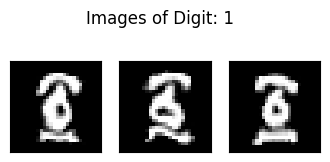

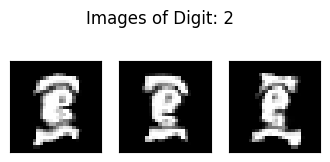

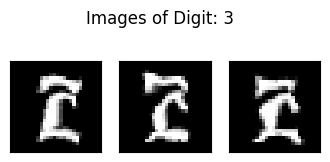

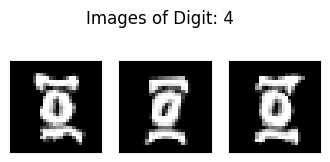

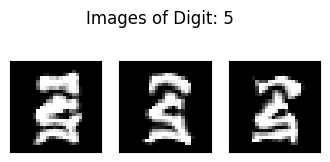

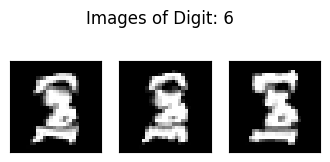

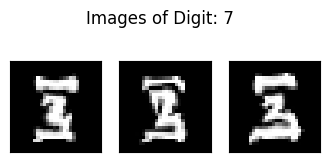

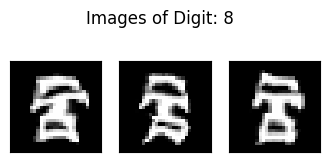

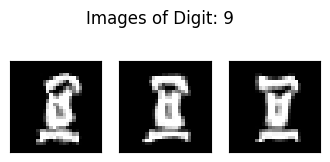

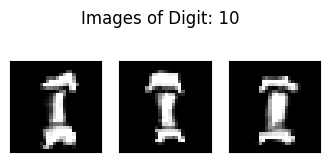

In [ ]:
for digit in range(1,11):

    #Find just the rows in X that are an image of this particular digit
    df_digit_subset=X[df['label']==digit]

    #Set up the plot
    fig, ax = plt.subplots(1, 3, figsize=(4, 2))
    plt.suptitle('Images of Digit: '+ str(digit))

    #Visualize the first three images that are of this digit
    for i in range(0,3):
        #First, reshape the flattened 64 pixel array into an 8-by-8 numpy array and unscale the data (ie. multiply by 255)
        object_image = np.array(df_digit_subset.iloc[i]).reshape((28, 28))*255

        #Then show the image
        ax[i].imshow(object_image, cmap='gray')
        ax[i].grid(False)
        ax[i].set_xticks([])
        ax[i].set_yticks([])
    plt.show()

There was no missing values and because the dataset is a MNIST dataset with images of digits, there are no outliers. As any value other than 0 is a pixel that we'll use. We argue that we don't have noise as all other pixels are a black background so their values are 0 having no impact on the values that are not 0.

## 4. Basic Descriptive Analytics

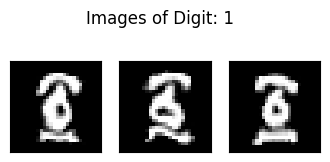

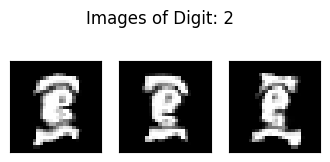

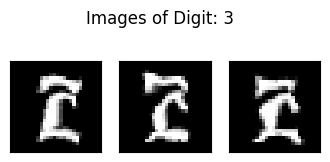

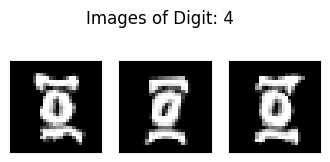

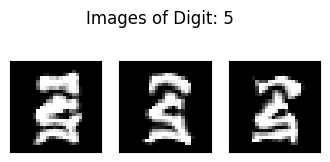

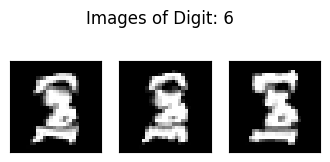

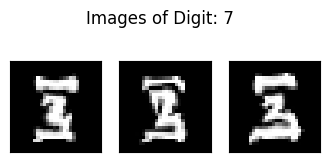

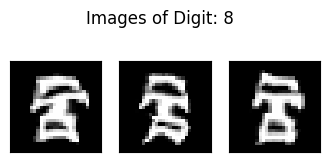

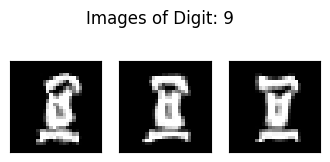

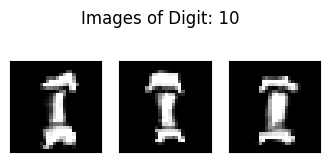

In [ ]:
for digit in range(1,11):

    #Find just the rows in X that are an image of this particular digit
    df_digit_subset=X[df['label']==digit]

    #Set up the plot
    fig, ax = plt.subplots(1, 3, figsize=(4, 2))
    plt.suptitle('Images of Digit: '+ str(digit))

    #Visualize the first three images that are of this digit
    for i in range(0,3):
        #First, reshape the flattened 64 pixel array into an 8-by-8 numpy array and unscale the data (ie. multiply by 255)
        object_image = np.array(df_digit_subset.iloc[i]).reshape((28, 28))*255

        #Then show the image
        ax[i].imshow(object_image, cmap='gray')
        ax[i].grid(False)
        ax[i].set_xticks([])
        ax[i].set_yticks([])
    plt.show()

In [ ]:
df_digit_averages=df.groupby(['label']).mean()
df_digit_averages

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
label,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.039604,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.010870,0.000000,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.088496,1.106195,0.867257,0.123894,0.008850,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.010204,0.387755,0.071429,0.010204,0.000000,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.009009,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.385321,0.036697,0.0,0.0,0.0,0.0,0.0


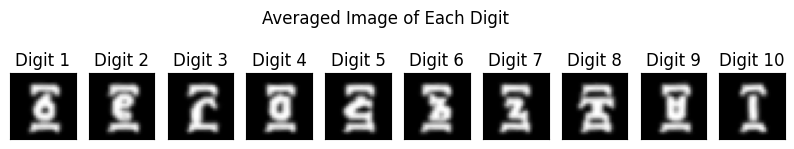

In [ ]:
#Set up the plot
fig, ax = plt.subplots(1, 10, figsize=(10, 2))
plt.suptitle('Averaged Image of Each Digit')

for digit in range(10):
    object_image = np.array(df_digit_averages.iloc[digit]).reshape((28, 28))*255

    #Then show the image
    ax[digit].imshow(object_image, cmap='gray')
    ax[digit].grid(False)
    ax[digit].set_xticks([])
    ax[digit].set_yticks([])
    ax[digit].set_title('Digit %s'%str(digit+1))
plt.show()

We have averaged all the images for each of the digits to get an idea of that the digits are supposed to look like

## 5. Scaling Decisions

The dataset is normalized for the Fuzzy C-means and K-means algorithm. This is done to improve training time.

The dataset is then mean-scaled for PCA to allow for the correct computation of the components.

## 6. Clusterability and Clustering Structure

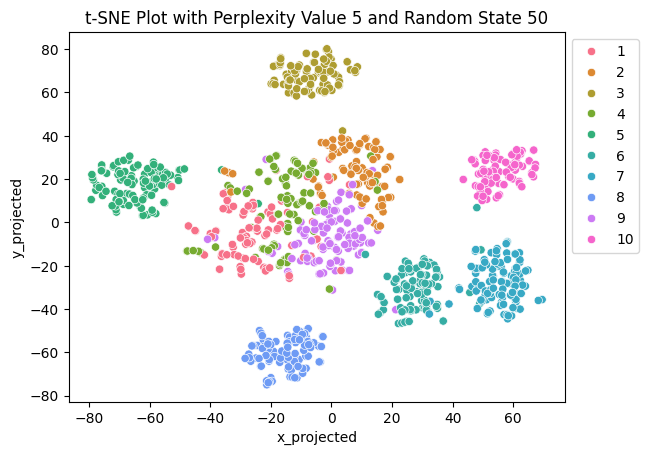

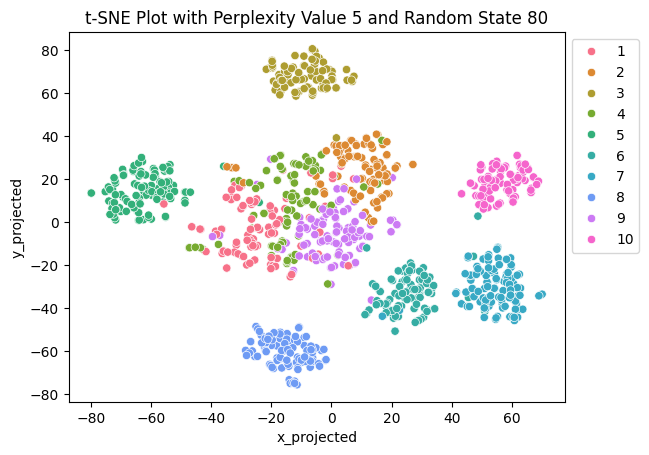

--------------------------------------------


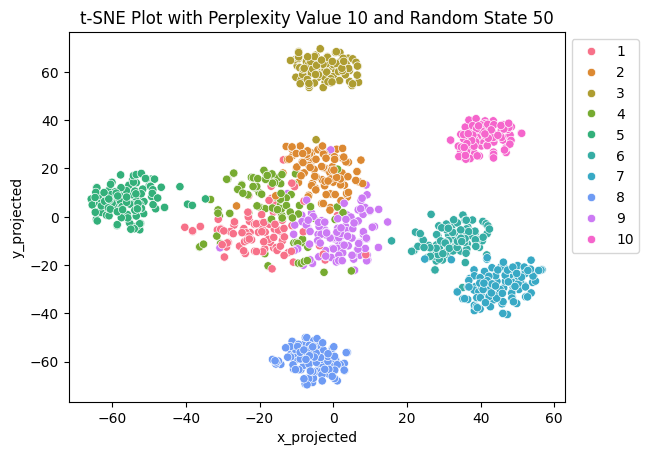

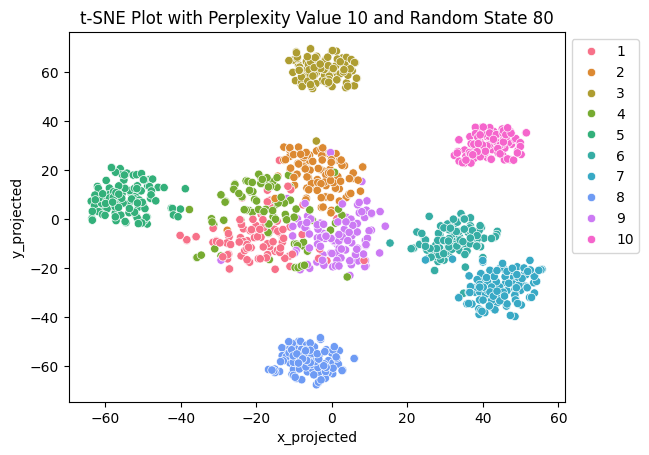

--------------------------------------------


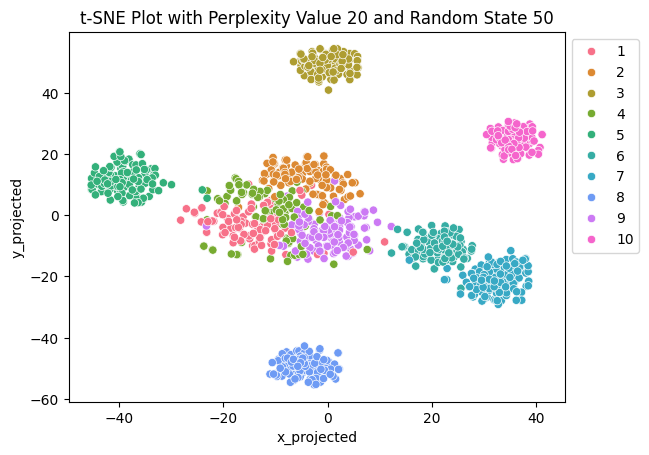

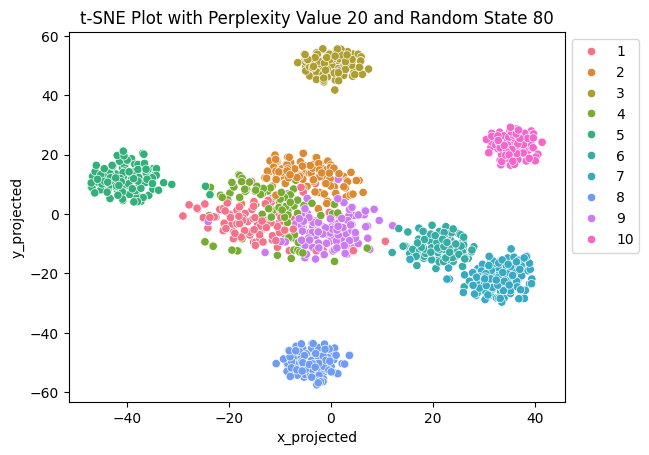

--------------------------------------------


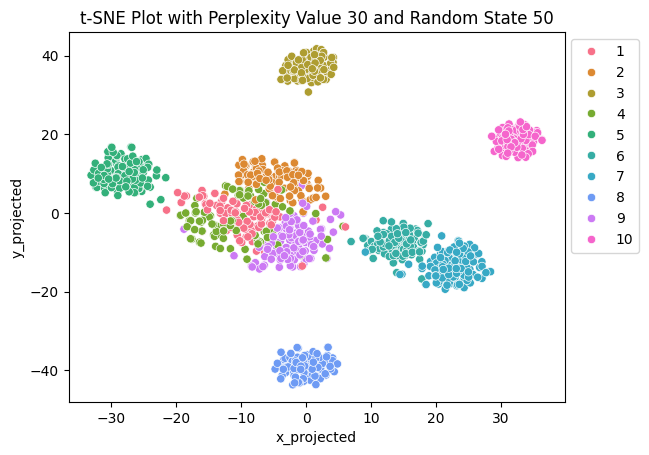

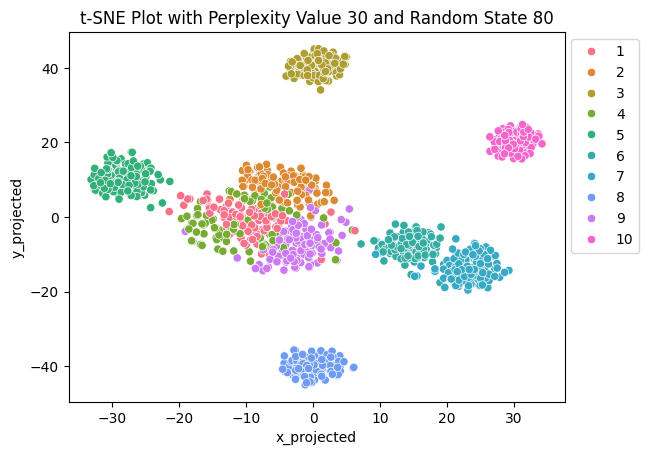

--------------------------------------------


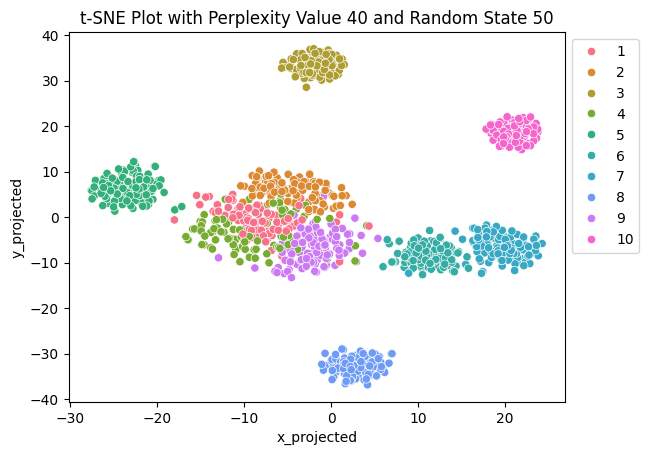

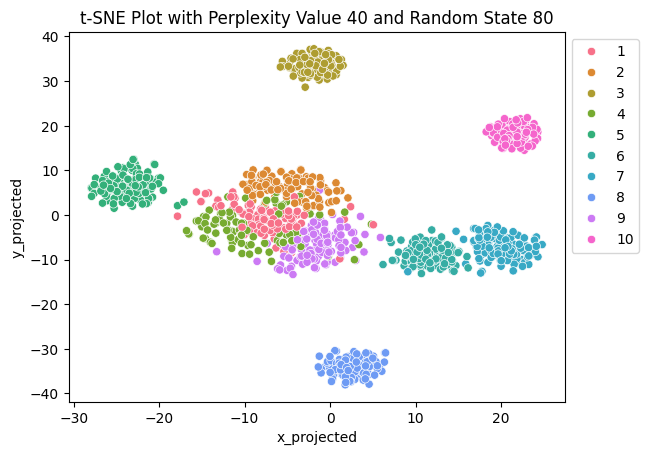

--------------------------------------------


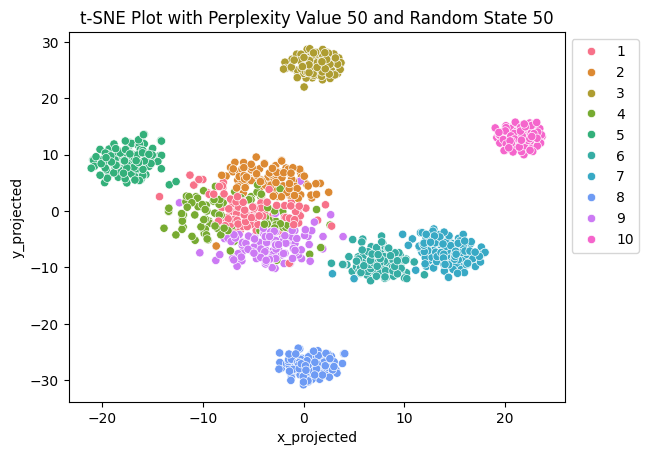

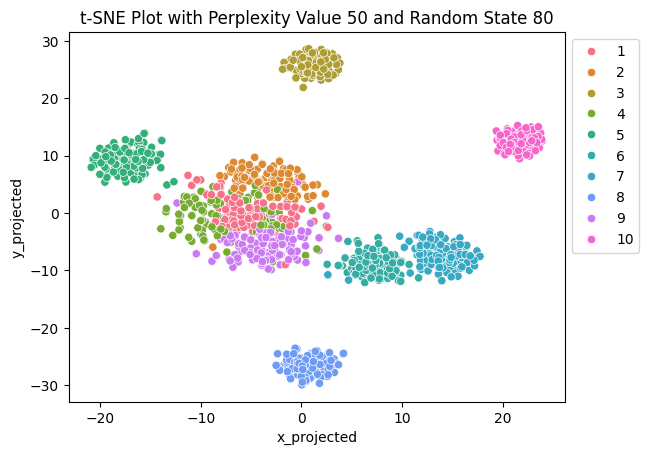

--------------------------------------------


In [ ]:
for perp in [5,10, 20, 30, 40, 50]:
    for rs in [50,80]:
        tsne = TSNE(n_components=2, perplexity=perp, random_state=rs)
        data_tsne = tsne.fit_transform(X)
        df_tsne = pd.DataFrame(data_tsne, columns=['x_projected', 'y_projected'])
        df_combo = pd.concat([df, df_tsne], axis=1)
        sns.scatterplot(x='x_projected',y='y_projected', hue='label', palette=sns.color_palette("husl", 10), data=df_combo)
        plt.title('t-SNE Plot with Perplexity Value %s and Random State %s' %(perp, rs))
        plt.legend(bbox_to_anchor=(1,1))
        plt.show()
    print('--------------------------------------------')

Our analysis suggests that the dataset is clusterable since the t-SNE plots with perplexity values of 5,10, 20, 30, 40, and 50 shows at least 6 distinct clusters. t-SNE plots shows that there are 6-7 clusters in the data that are spherical. If we use 7 clusters, all the other clusters are blanaced in size except one hige cluster mostly comprised of "1", "2","4",and "9" and other than the cluster that are mostly comprised of "6" and cluster that are mostly comprise of "7" other clusters are well-separated. However, those two clusters are not well-separated to each other. We do not have any evidence of nested cluster relationships in this dataset

In [ ]:
perp = 50
rs = 80
tsne = TSNE(n_components=2, perplexity=perp, random_state=rs)
data_tsne = tsne.fit_transform(X)
df_tsne = pd.DataFrame(data_tsne, columns=['x_projected', 'y_projected'])
df_combo = pd.concat([df, df_tsne], axis=1)
sns.scatterplot(x='x_projected',y='y_projected', hue='label', palette=sns.color_palette("husl", 10), data=df_combo)
plt.title('t-SNE Plot with Perplexity Value %s and Random State %s' %(perp, rs))
plt.legend(bbox_to_anchor=(1,1))
plt.show()

The t-SNE algorithm suggests that an image observations
 have a clustering structure. The t-SNE plots with perplexity values of 10,20,30,40, and 50 we see 6-7 clusters. We see a large cluster in the center with moderate density and 4 very distinct, denser clusters in the surroundings. There is a medium sized clusters that is composed of 2 smaller cluster to the right of the largest cluster. The clusters are all spherical with similar density and has good seperation with each other.

*Caution

1. Outliers -> t-SNE plots do not indicate whether or not the dataset has outliers.
2. Sparsity -> t-SNE plots do not reflect cluster sparsity.
3. Distance -> t-SNE plots do not preserve the distances between clusters.
4. Centroid -> t-SNE plots do not help determine centroid or other summary statistics of the original clusters.


## 7. Clustering Algorithm Selection Motivation

Why did we do Fuzzy c means

We chose to use Fuzzy C-Means clustering to process the dataset because the t-SNE visualization showed that the data could be clustered, but the middle cluster contained data with 4 different labels. This suggests that there may be overlap or ambiguity in the categories of these data points, which is what FCM can effectively handle.

We chose to use PCA to downsample the images and explore the relationship between the different digits, as there were some digits were very distinct and other were not as suggetsed by the T-SNE plots

Lastly, since the clusters are mostly spherical, we also choose k-means as the alternative algorithm to compare against fuzzy c-means

## 8. Clustering Algorithm #1



### Fuzzy C means

#### Parameter Selection

------------------------------------------
Analysis for c=10 and p=1.01
Normalized Dunning Partitional Coefficient:  0.9941435746241325
Final Objective Function Value:  22173.29556427074


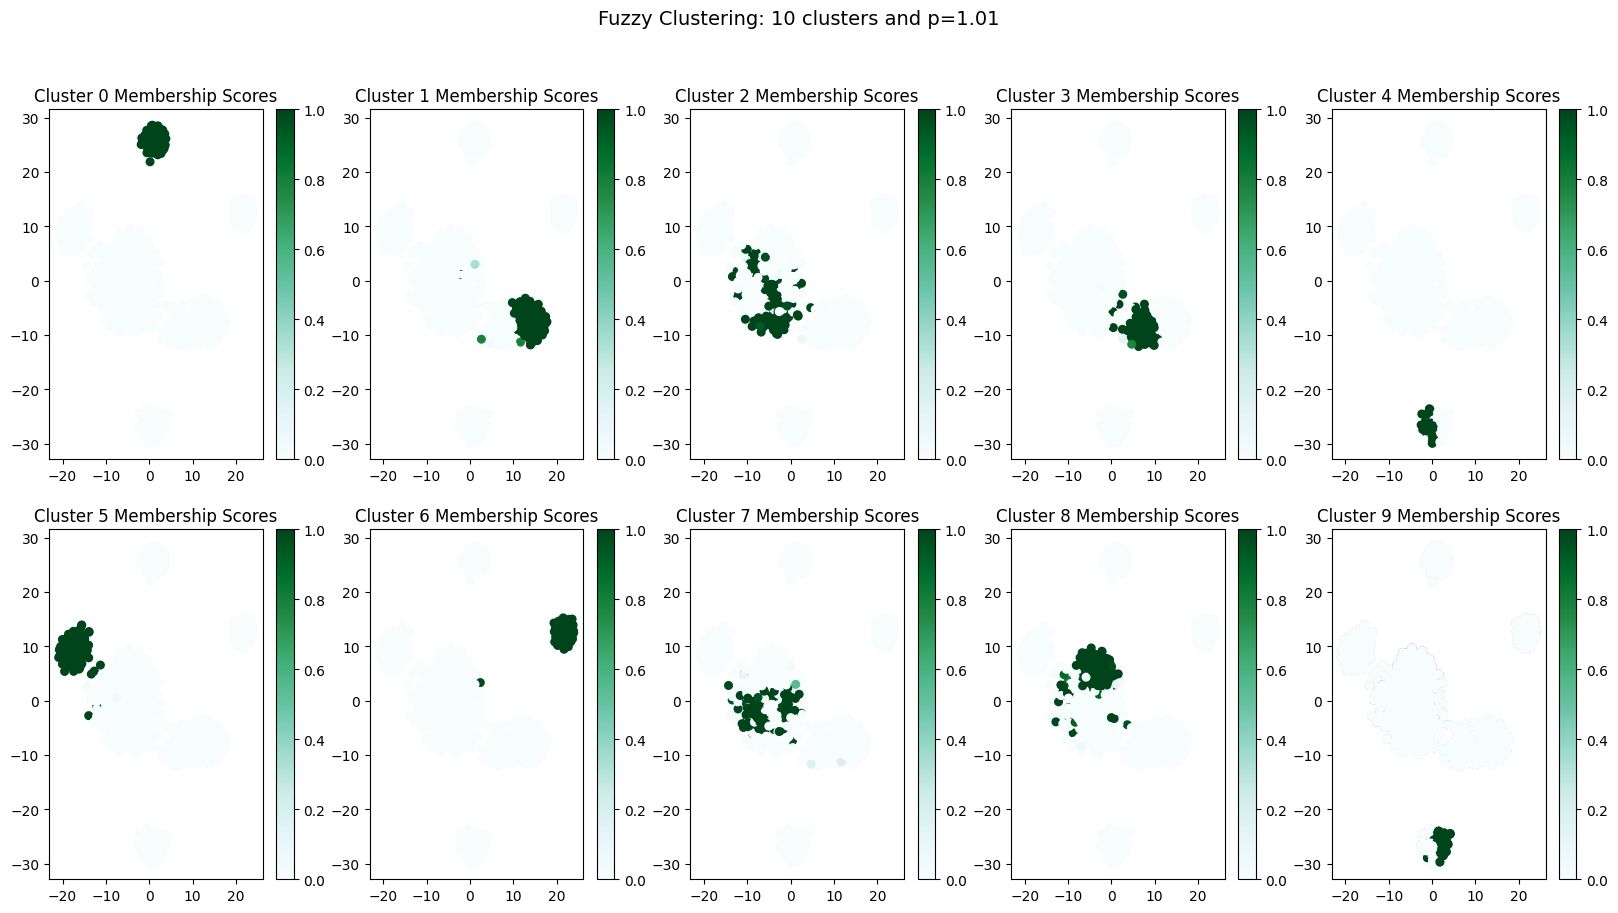

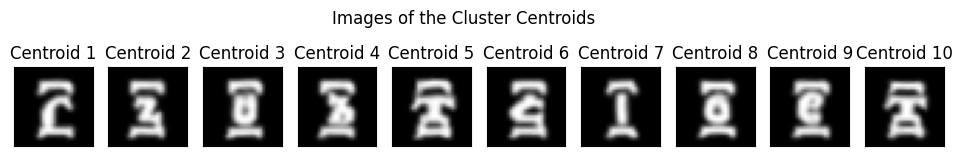

Highest Cluster Membership Scores (Sorted)
948    0.550527
949    0.775960
672    0.778837
305    0.793246
290    0.797391
         ...   
744    1.000000
451    1.000000
742    1.000000
445    1.000000
0      1.000000
Length: 1000, dtype: float64


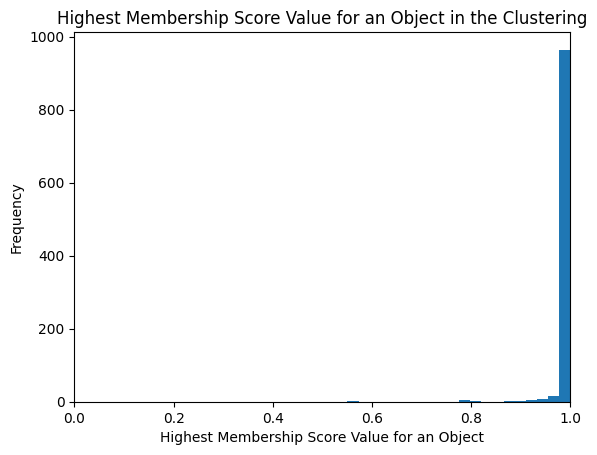

------------------------------------------
Analysis for c=10 and p=1.0942857142857143
Normalized Dunning Partitional Coefficient:  0.7608143440849326
Final Objective Function Value:  21735.99118695298


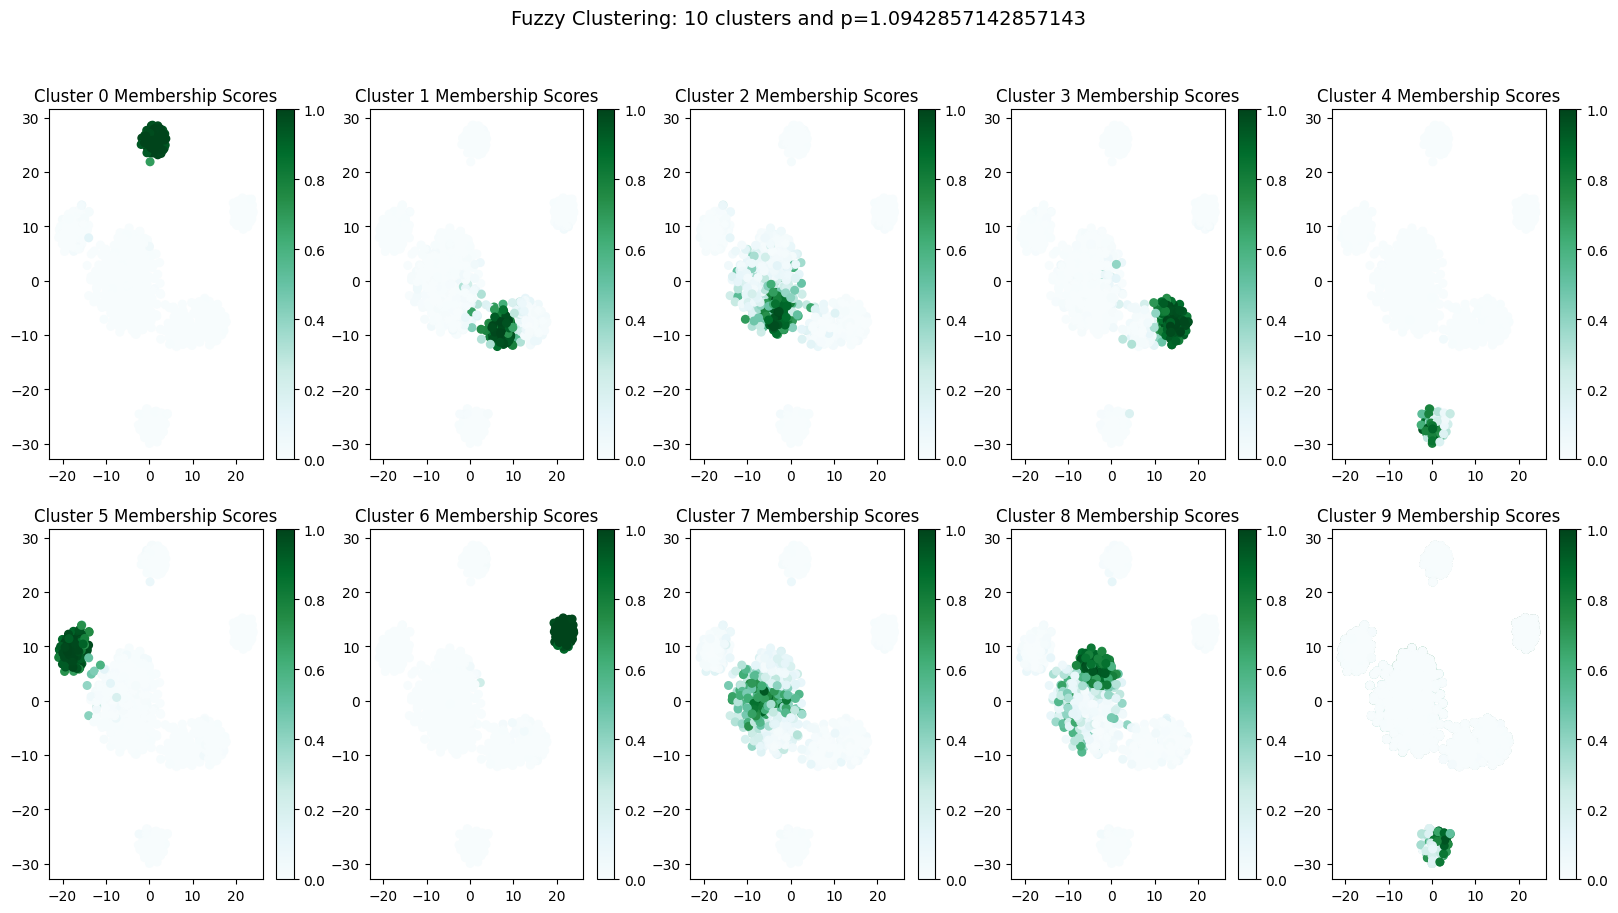

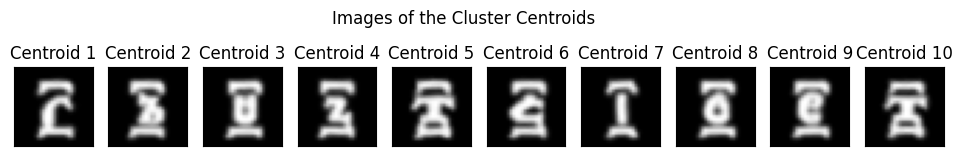

Highest Cluster Membership Scores (Sorted)
672    0.309644
949    0.326405
87     0.327376
508    0.328962
79     0.334325
         ...   
905    0.999993
638    0.999995
722    0.999996
540    0.999998
530    0.999999
Length: 1000, dtype: float64


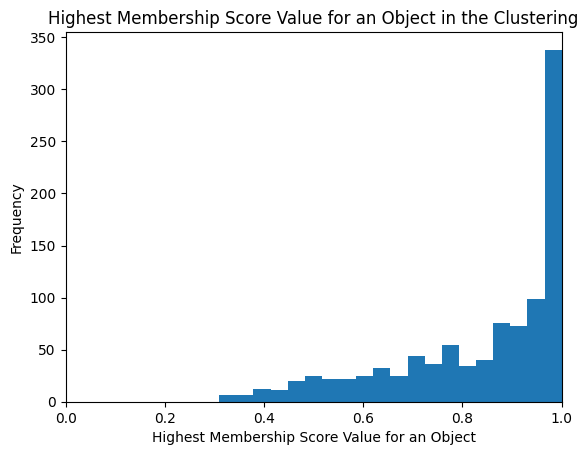

------------------------------------------
Analysis for c=10 and p=1.1785714285714286
Normalized Dunning Partitional Coefficient:  0.41909468913682324
Final Objective Function Value:  19948.131498589144


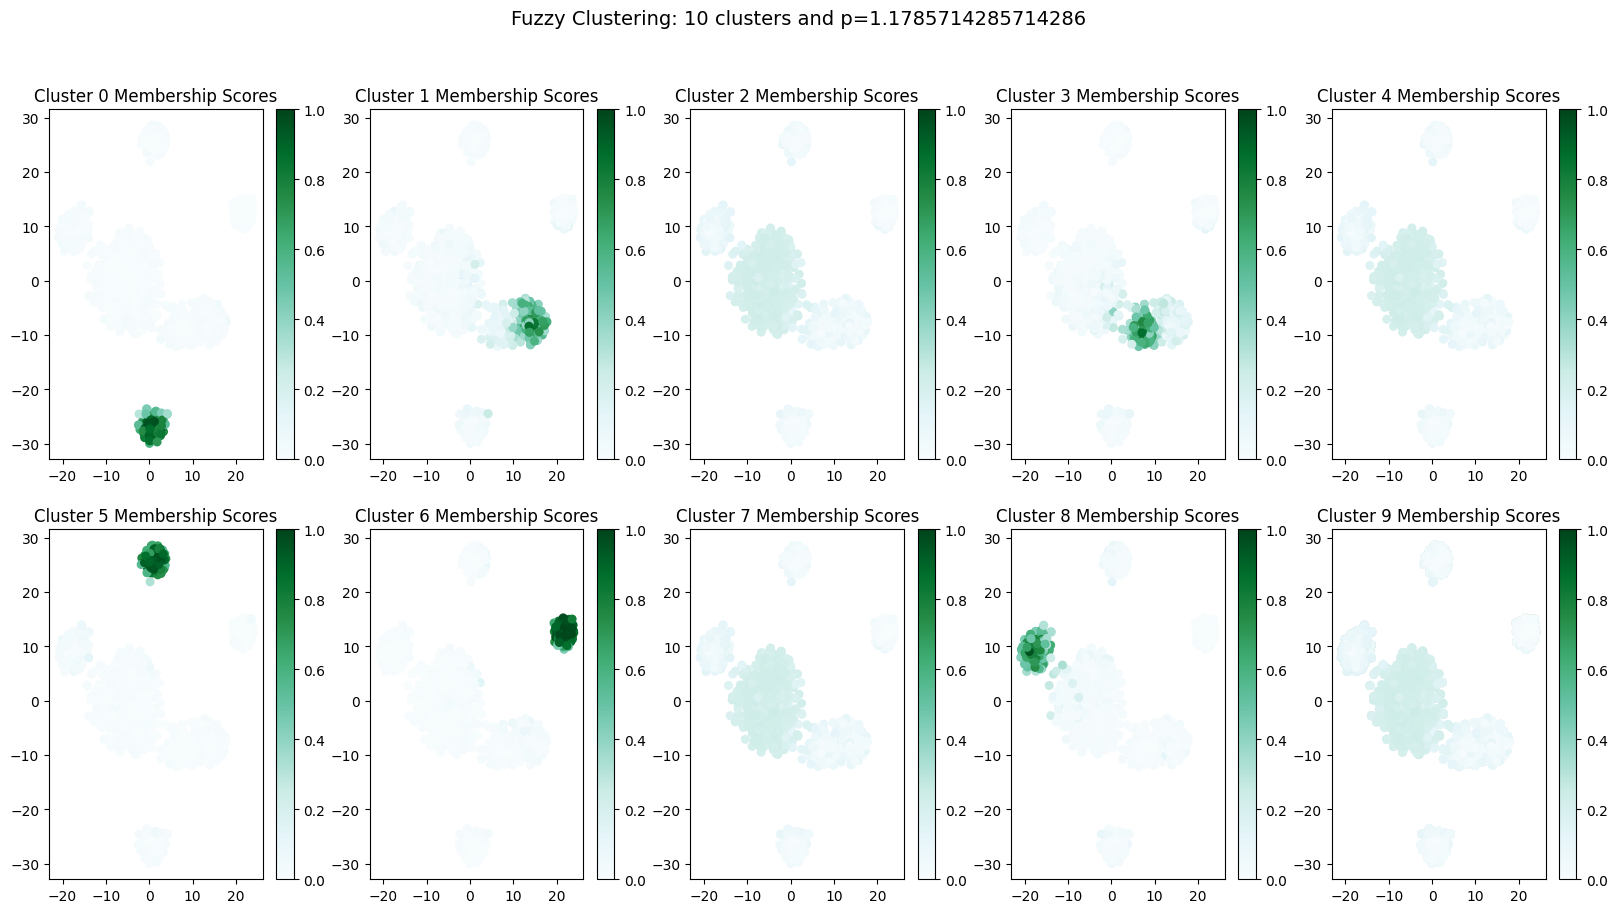

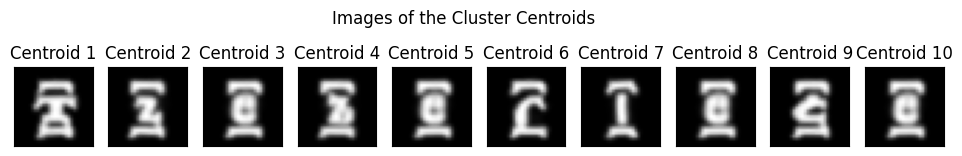

Highest Cluster Membership Scores (Sorted)
439    0.152013
176    0.160068
624    0.171648
61     0.173335
172    0.177766
         ...   
638    0.993645
905    0.994202
722    0.994613
540    0.996394
530    0.997489
Length: 1000, dtype: float64


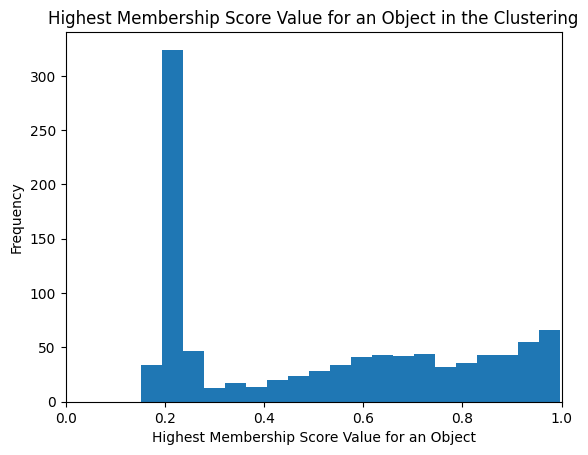

------------------------------------------
Analysis for c=10 and p=1.262857142857143
Normalized Dunning Partitional Coefficient:  0.10000000000009139
Final Objective Function Value:  17390.78540590682


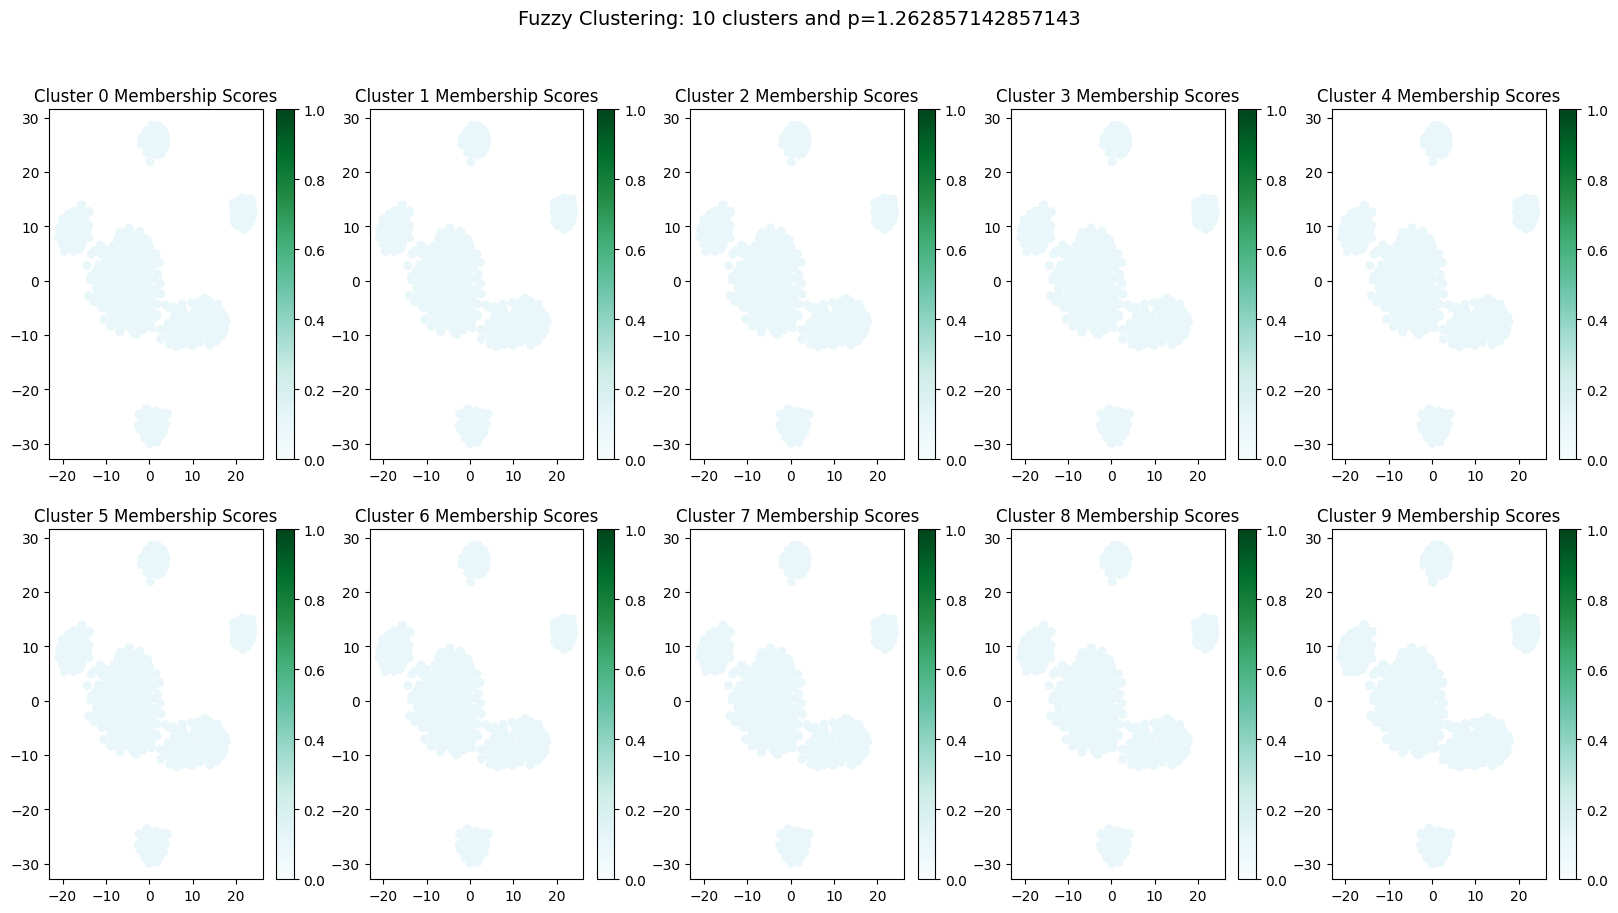

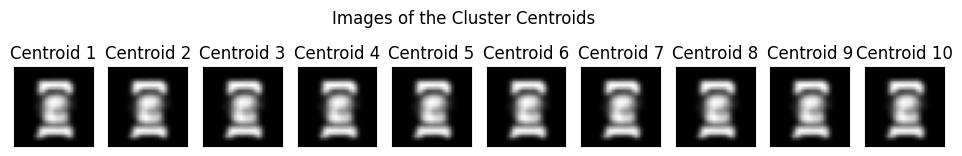

Highest Cluster Membership Scores (Sorted)
492    0.1
59     0.1
353    0.1
318    0.1
414    0.1
      ... 
183    0.1
366    0.1
468    0.1
917    0.1
581    0.1
Length: 1000, dtype: float64
------------------------------------------
Analysis for c=10 and p=1.3471428571428572
Normalized Dunning Partitional Coefficient:  0.10000000000000452
Final Objective Function Value:  14322.98317777381


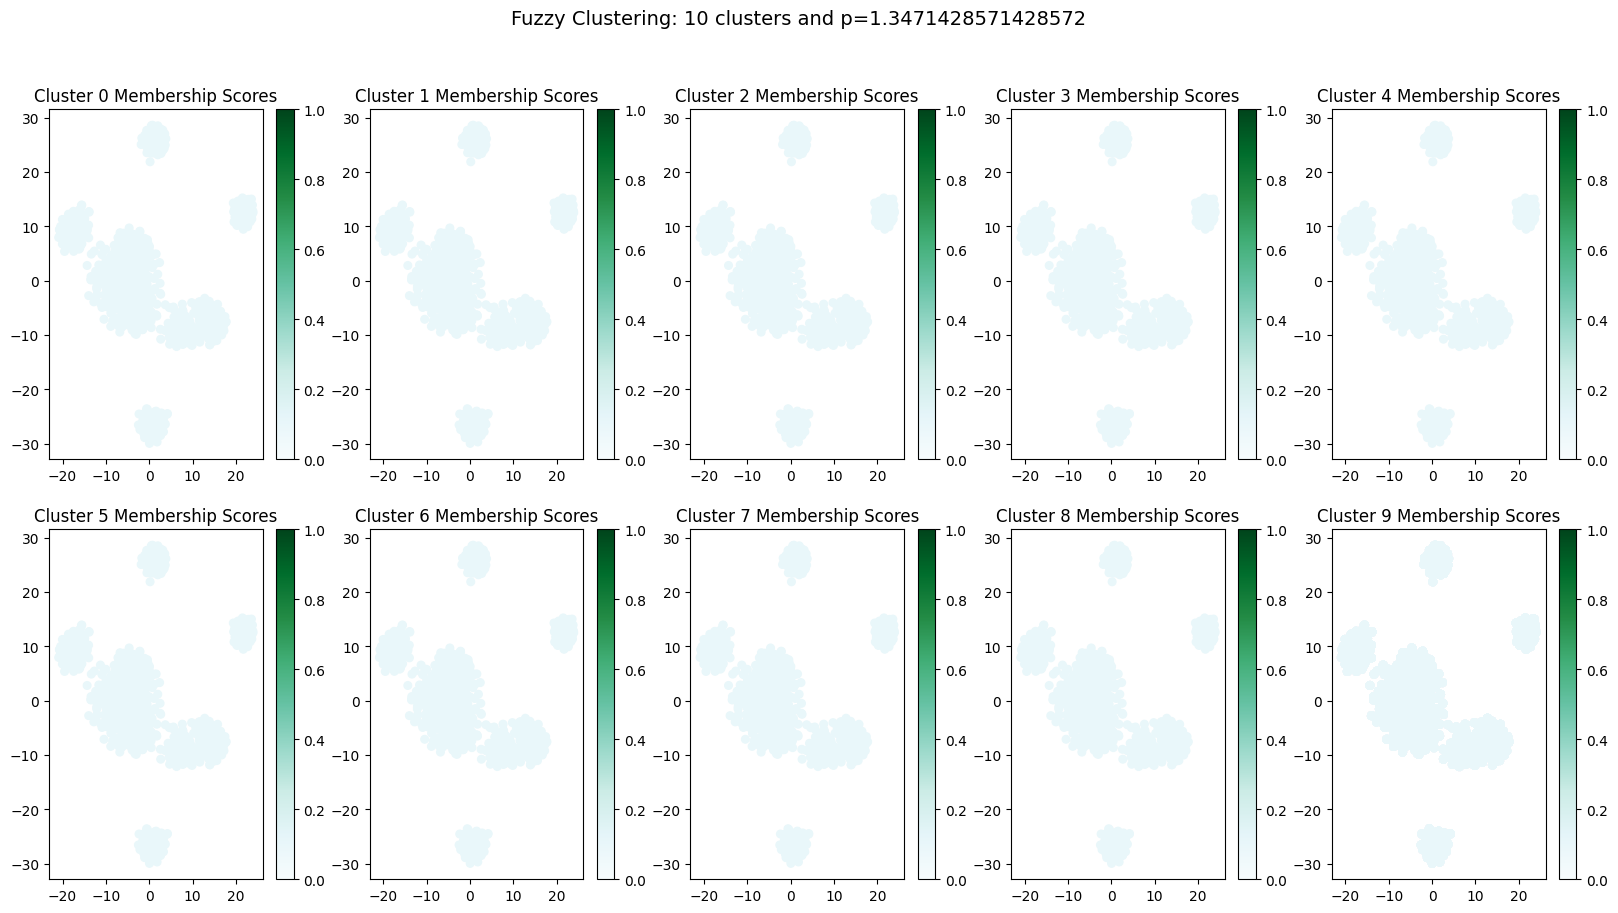

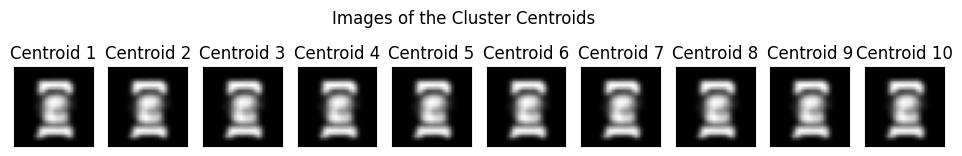

Highest Cluster Membership Scores (Sorted)
492    0.1
59     0.1
353    0.1
318    0.1
414    0.1
      ... 
183    0.1
366    0.1
468    0.1
917    0.1
581    0.1
Length: 1000, dtype: float64
------------------------------------------
Analysis for c=10 and p=1.4314285714285715
Normalized Dunning Partitional Coefficient:  0.10000000000000119
Final Objective Function Value:  11796.35320214547


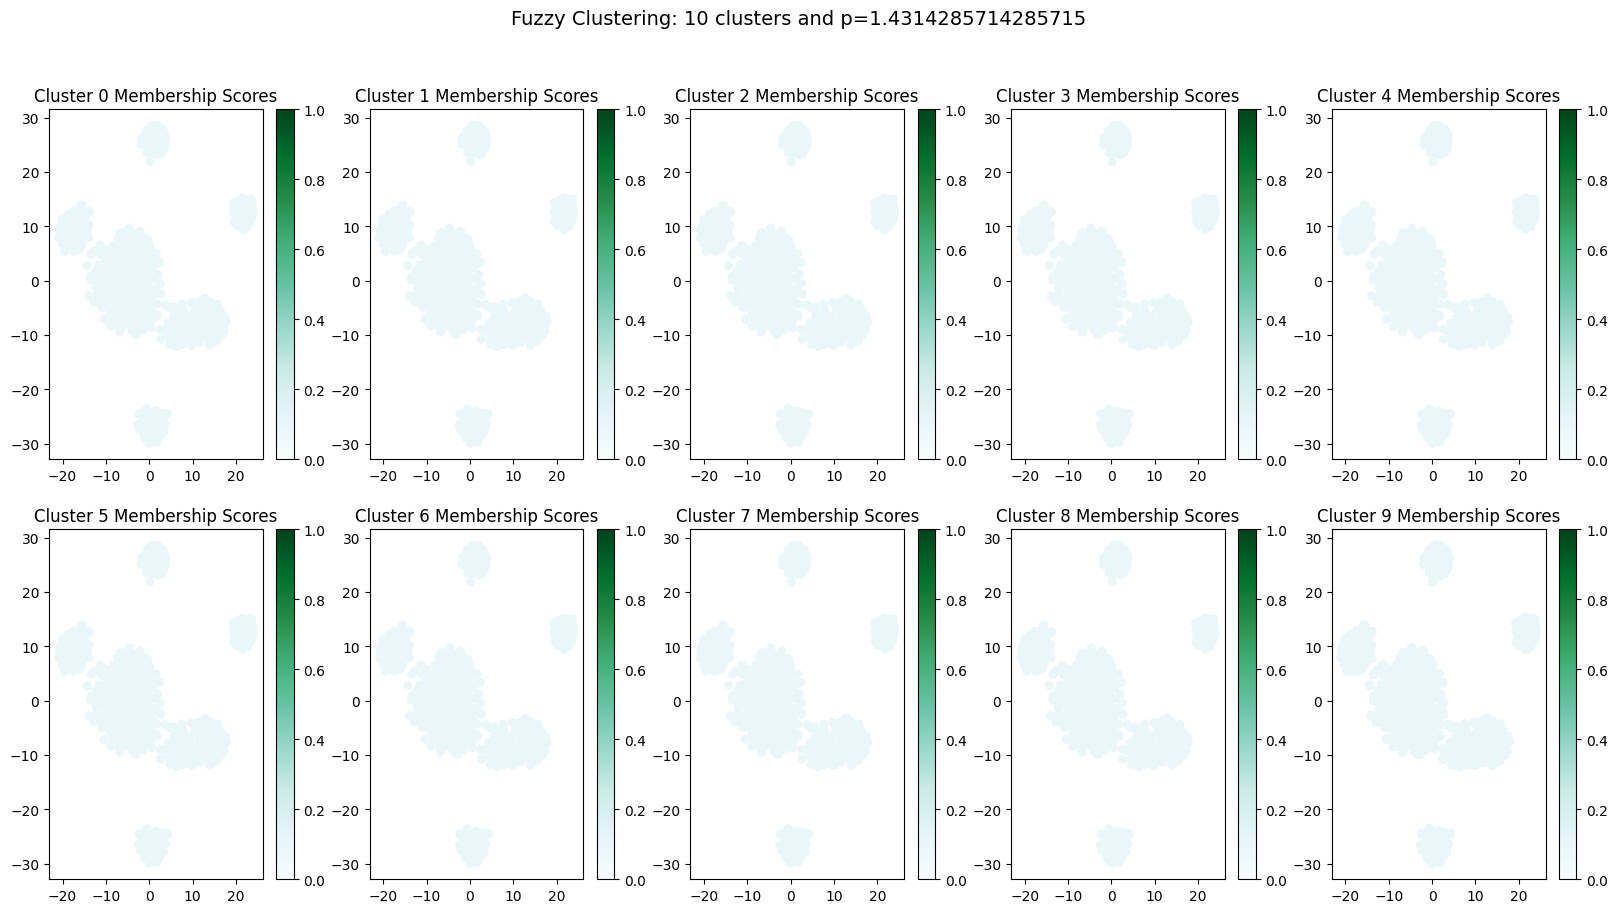

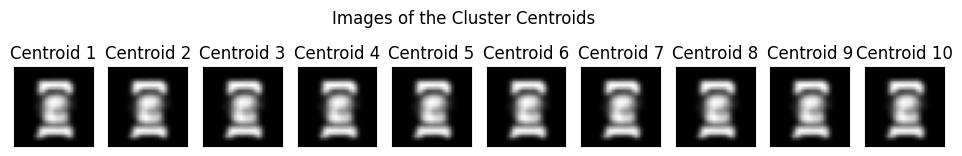

Highest Cluster Membership Scores (Sorted)
492    0.1
59     0.1
353    0.1
318    0.1
414    0.1
      ... 
183    0.1
366    0.1
468    0.1
917    0.1
581    0.1
Length: 1000, dtype: float64
------------------------------------------
Analysis for c=10 and p=1.5157142857142858
Normalized Dunning Partitional Coefficient:  0.10000000000000074
Final Objective Function Value:  9715.430587512315


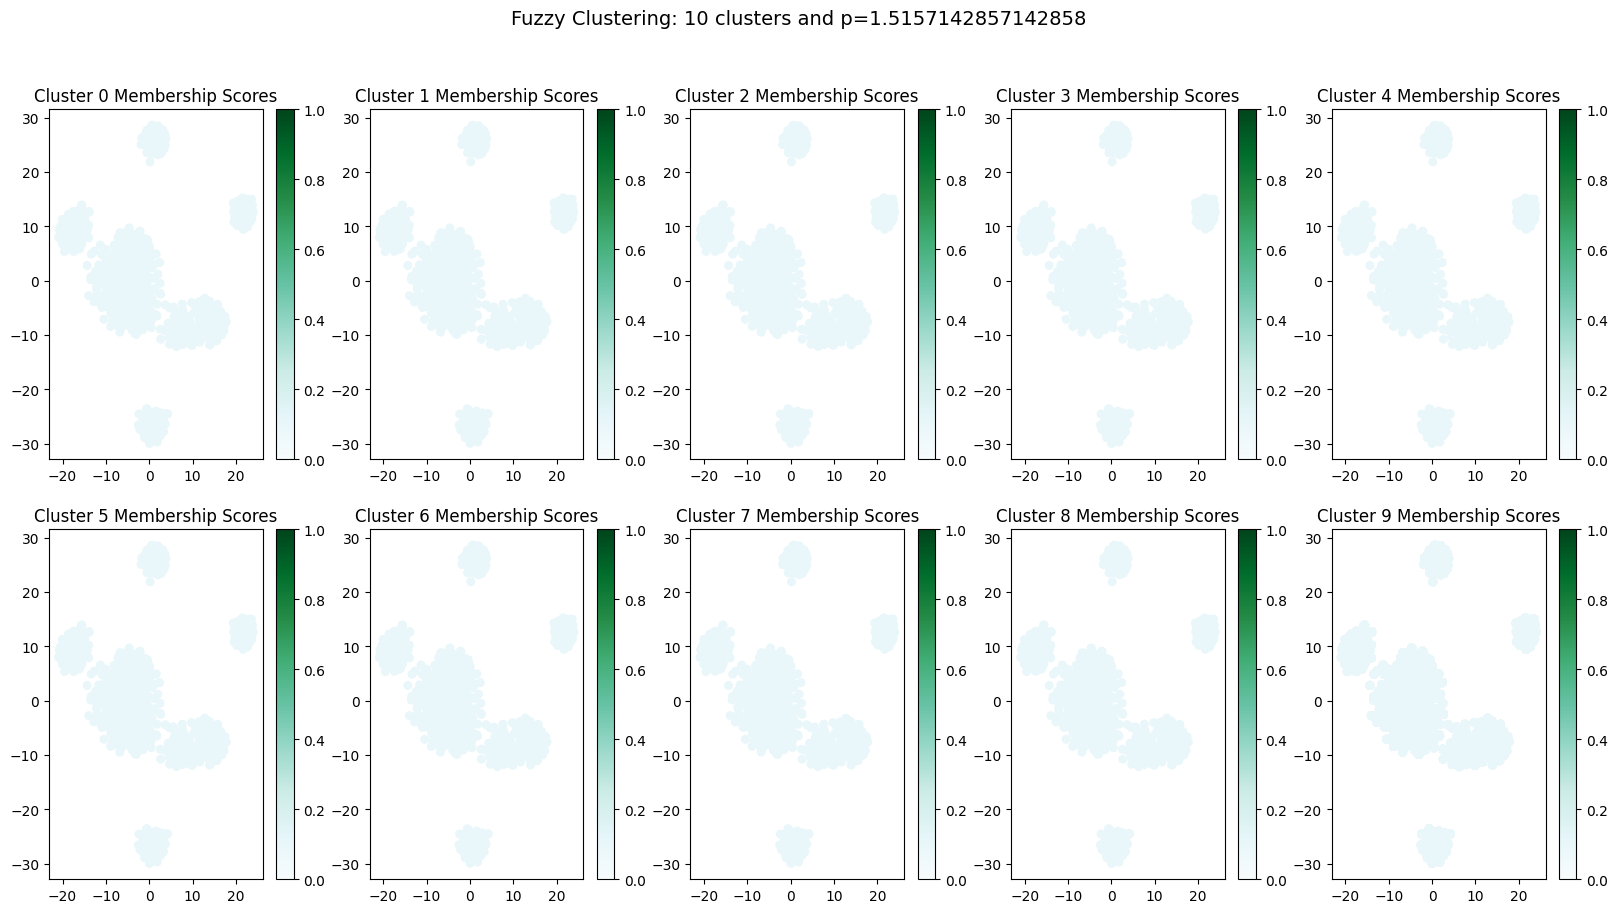

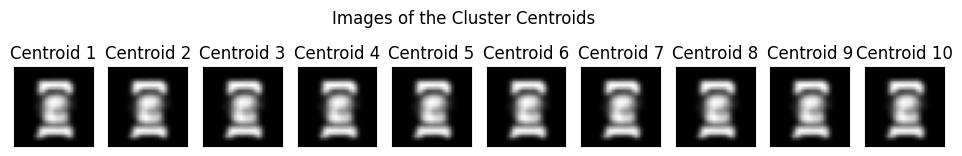

Highest Cluster Membership Scores (Sorted)
492    0.1
59     0.1
353    0.1
318    0.1
414    0.1
      ... 
183    0.1
366    0.1
468    0.1
917    0.1
581    0.1
Length: 1000, dtype: float64
------------------------------------------
Analysis for c=10 and p=1.6
Normalized Dunning Partitional Coefficient:  0.10000000000000075
Final Objective Function Value:  8001.590820763395


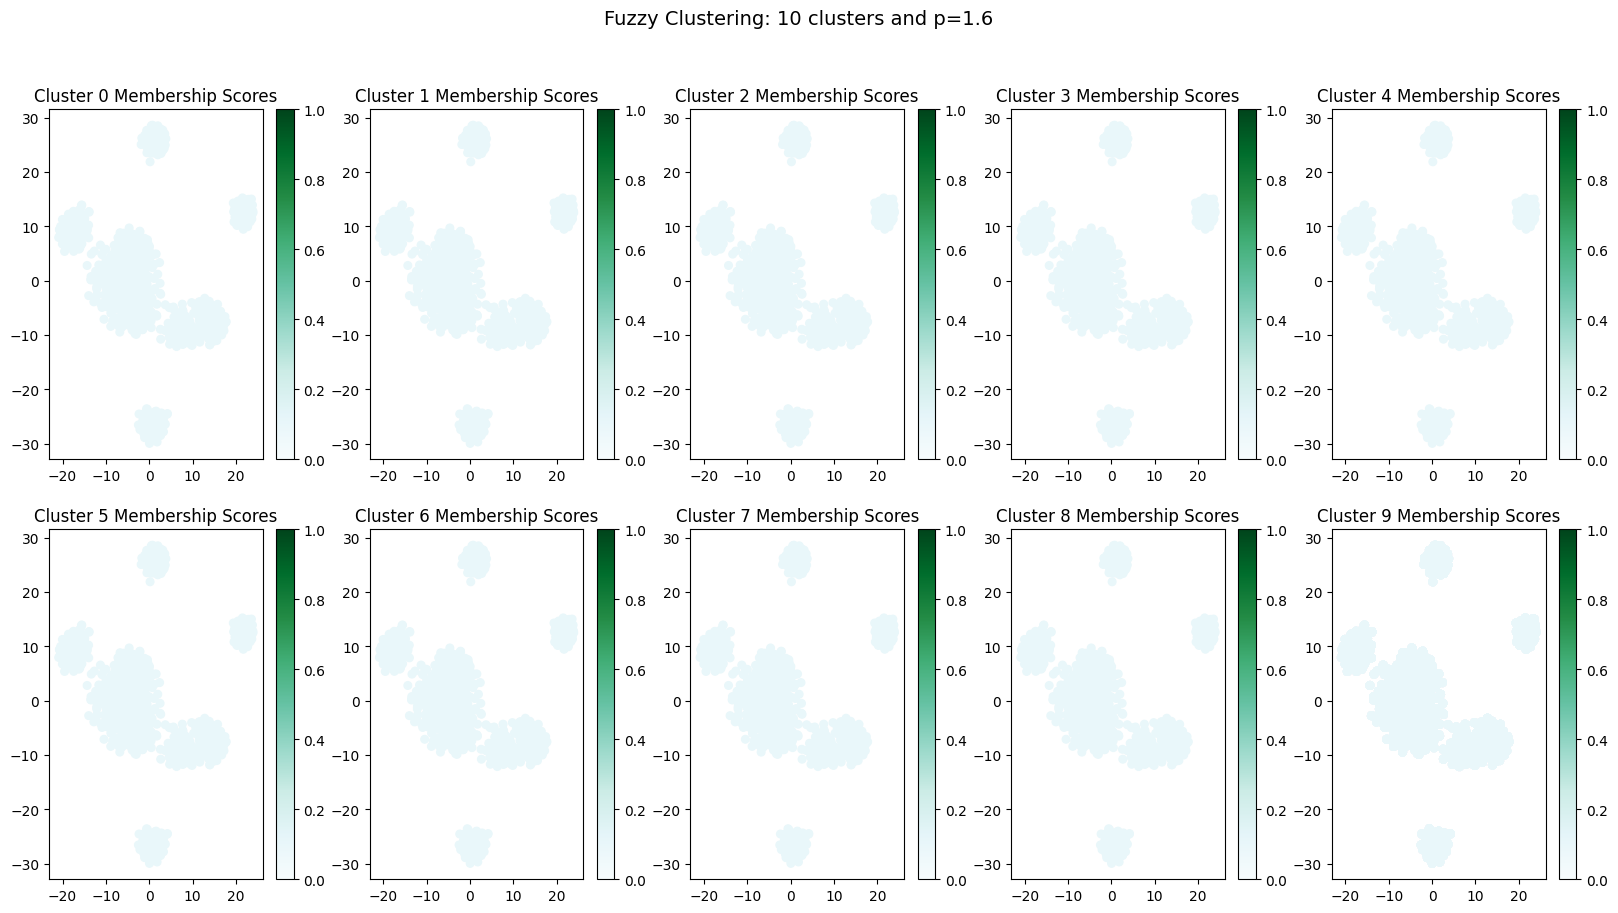

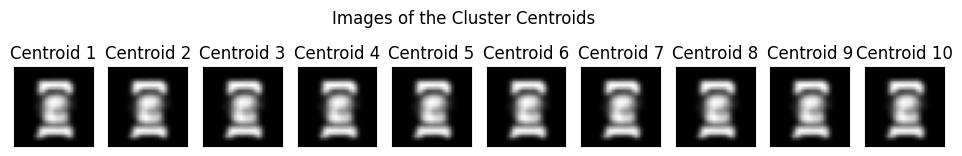

Highest Cluster Membership Scores (Sorted)
492    0.1
59     0.1
318    0.1
353    0.1
414    0.1
      ... 
183    0.1
366    0.1
468    0.1
917    0.1
581    0.1
Length: 1000, dtype: float64


In [ ]:
#Number of clusters
c=10

#List of cluster membership score matrices for each p
W_list = []

#List of normalized dunning partitional coefficient scores for each p
ndpc_list = []

#List of cluster centroids for each p
centroids_list=[]


for p in np.linspace(1.01, 1.6, 8):
    print('------------------------------------------')
    print('Analysis for c=%s and p=%s'%(c,p))


    #Cluster the data using these parameters
    centroids, W, _, _, obj_history, _, ndpc = cmeans(X.T, c=10, m=p, error=1e-6, maxiter=20000, seed=100)

    #Normalized Dunning Partitional Coefficient
    print('Normalized Dunning Partitional Coefficient: ', ndpc)
    print('Final Objective Function Value: ' , obj_history[len(obj_history)-1])

    #Update the lists
    W_list.append(W)
    ndpc_list.append(ndpc)
    centroids_list.append(centroids)

    #Color code t-SNE Plots
    fig, ax = plt.subplots(2, 5, figsize=(20, 10))
    plt.suptitle('Fuzzy Clustering: %s clusters and p=%s'%(c,p), fontsize=14)
    for i in range(0,10):

        #Create a column with cluster i membership scores
        df_combo['Cluster %s Membership Score'%str(i)]=W[i,:]

        #Plot the points, color coded by the membership score.
        points = plt.scatter(df_combo["x_projected"], df_combo["y_projected"],
                     c=df_combo['Cluster %s Membership Score'%str(i)],
                             s=30, cmap="BuGn",
                            vmin=0,
                            vmax=1)
        ax[int(np.floor(i/5)),int(i%5)].scatter(df_combo["x_projected"], df_combo["y_projected"],
                     c=df_combo['Cluster %s Membership Score'%str(i)],
                                                s=30, cmap="BuGn",
                                               vmin=0,
                                               vmax=1)

        fig.colorbar(points, ax=ax[int(np.floor(i/5)),int(i%5)])
        ax[int(np.floor(i/5)),int(i%5)].set_title('Cluster %s Membership Scores'%(str(i)))
    plt.show()


    #Let's visualize and describe the cluster centroids for this clustering
    #Set up the plot
    fig, ax = plt.subplots(1, 10, figsize=(12, 2))
    plt.suptitle('Images of the Cluster Centroids')

    for j in range(10):
        #Turn the centroids into a dataframe
        df_centroids=pd.DataFrame(centroids, columns=X.columns)
        #First, reshape the flattened 64 pixel array into an 8-by-8 numpy array and unscale the data (ie. multiply by 255)
        object_image = np.array(df_centroids.iloc[j]).reshape((28,28))*255

        #Then show the image
        ax[j].imshow(object_image, cmap='gray')
        ax[j].grid(False)
        ax[j].set_xticks([])
        ax[j].set_yticks([])
        ax[j].set_title('Centroid %s'%str(j+1))
    plt.show()

    #Let's get the highest membership score for the clustering for each object in the dataset
    cluster_columns=['Cluster %s Membership Score'%(str(i)) for i in range(0,10)]
    df_membership=pd.DataFrame(W.T, columns=cluster_columns)
    highest_membership_scores=df_membership.T.max()

    print('Highest Cluster Membership Scores (Sorted)')
    print(highest_membership_scores.sort_values())

    if highest_membership_scores.max()>highest_membership_scores.min()+.00001:
        plt.hist(highest_membership_scores, bins=20)
        plt.title('Highest Membership Score Value for an Object in the Clustering')
        plt.xlabel('Highest Membership Score Value for an Object')
        plt.ylabel('Frequency')
        plt.xlim([0,1])
        plt.show()

we will choose to use fuzzy c-means with c=10 clusters and p=1.09. While we can gain some insight many of these values of p, we will choose to use the fuzzy clustering produced by p=1.09 as it allows us to classify most objects whose's membership is relatively certain, reflect the uncertainty of the cluster assignment of "straddle nodes", and also determine more information about which clusters are fuzzier than others.

Analysis for c=10 and p=1.09
Normalized Dunning Partitional Coefficient:  0.778772261418633
Final Objective Function Value:  21781.333826866456


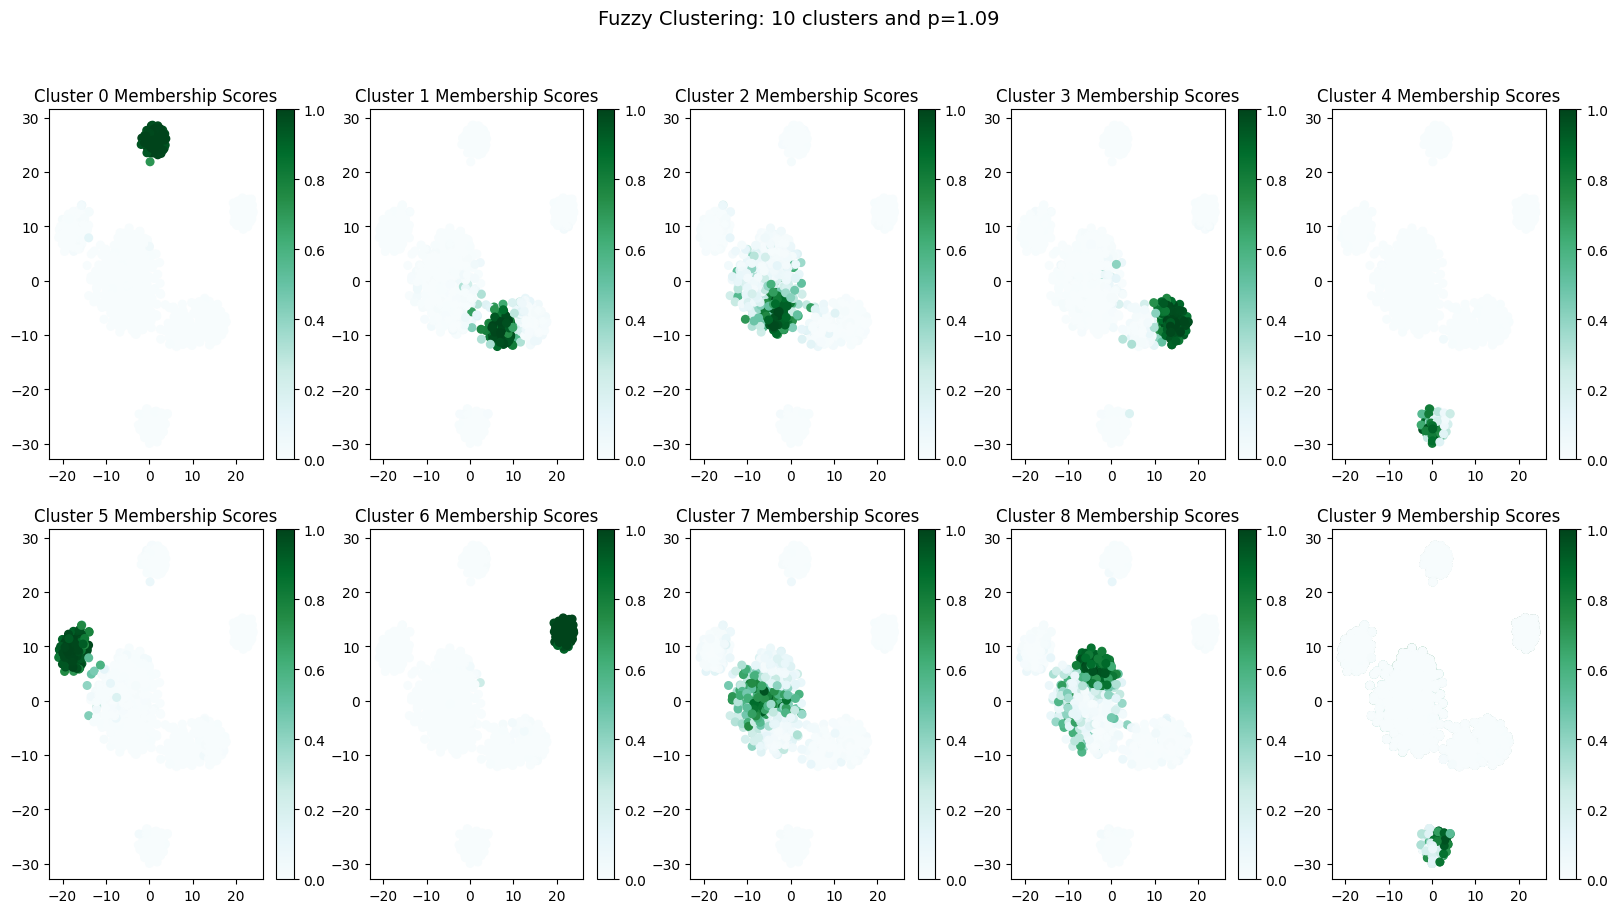

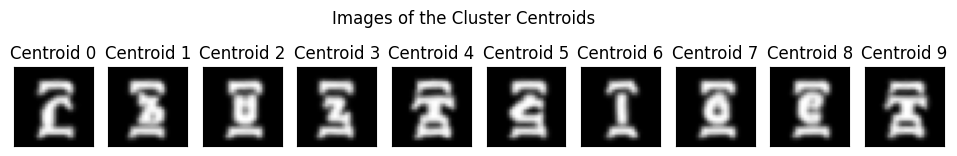

Highest Cluster Membership Scores (Sorted)
672    0.316467
949    0.335058
87     0.337313
79     0.338378
237    0.342566
         ...   
905    0.999996
638    0.999997
722    0.999998
540    0.999999
530    0.999999
Length: 1000, dtype: float64


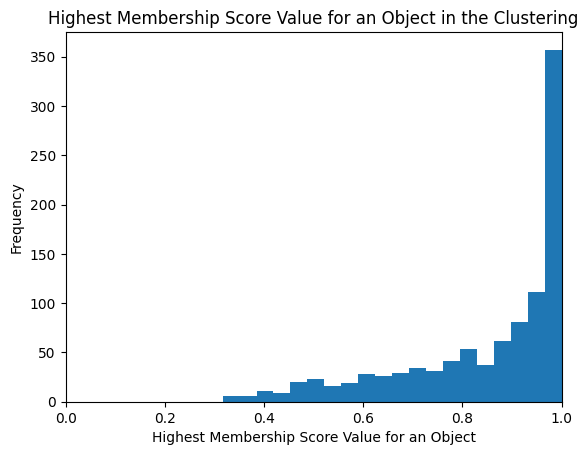

In [ ]:
c=10
p=1.09

print('Analysis for c=%s and p=%s'%(c,p))


#Cluster the data using these parameters
centroids, W, _, _, obj_history, _, ndpc = cmeans(X.T, c=10, m=p, error=1e-6, maxiter=20000, seed=100)

#Normalized Dunning Partitional Coefficient
print('Normalized Dunning Partitional Coefficient: ', ndpc)
print('Final Objective Function Value: ' , obj_history[len(obj_history)-1])

#Update the lists
W_list.append(W)
ndpc_list.append(ndpc)
centroids_list.append(centroids)

#Color code t-SNE Plots
fig, ax = plt.subplots(2, 5, figsize=(20, 10))
plt.suptitle('Fuzzy Clustering: %s clusters and p=%s'%(c,p), fontsize=14)
for i in range(0,10):

    #Create a column with cluster i membership scores
    df_combo['Cluster %s Membership Score'%str(i)]=W[i,:]

    #Plot the points, color coded by the membership score.
    points = plt.scatter(df_combo["x_projected"], df_combo["y_projected"],
                 c=df_combo['Cluster %s Membership Score'%str(i)],
                         s=30, cmap="BuGn",
                        vmin=0,
                        vmax=1)
    ax[int(np.floor(i/5)),int(i%5)].scatter(df_combo["x_projected"], df_combo["y_projected"],
                 c=df_combo['Cluster %s Membership Score'%str(i)],
                                            s=30, cmap="BuGn",
                                           vmin=0,
                                           vmax=1)

    fig.colorbar(points, ax=ax[int(np.floor(i/5)),int(i%5)])
    ax[int(np.floor(i/5)),int(i%5)].set_title('Cluster %s Membership Scores'%(str(i)))
plt.show()


#Let's visualize and describe the cluster centroids for this clustering
#Set up the plot
fig, ax = plt.subplots(1, 10, figsize=(12, 2))
plt.suptitle('Images of the Cluster Centroids')

for j in range(0,10):
    #Turn the centroids into a dataframe
    df_centroids=pd.DataFrame(centroids, columns=X.columns)
    #First, reshape the flattened 64 pixel array into an 8-by-8 numpy array and unscale the data (ie. multiply by 255)
    object_image = np.array(df_centroids.iloc[j]).reshape((28, 28))*255

    #Then show the image
    ax[j].imshow(object_image, cmap='gray')
    ax[j].grid(False)
    ax[j].set_xticks([])
    ax[j].set_yticks([])
    ax[j].set_title('Centroid %s'%str(j))
plt.show()

#Let's get the highest membership score for the clustering for each object in the dataset
cluster_columns=['Cluster %s Membership Score'%(str(i)) for i in range(0,10)]
df_membership=pd.DataFrame(W.T, columns=cluster_columns)
highest_membership_scores=df_membership.T.max()

print('Highest Cluster Membership Scores (Sorted)')
print(highest_membership_scores.sort_values())

if highest_membership_scores.max()>highest_membership_scores.min()+.00001:
    plt.hist(highest_membership_scores, bins=20)
    plt.title('Highest Membership Score Value for an Object in the Clustering')
    plt.xlabel('Highest Membership Score Value for an Object')
    plt.ylabel('Frequency')
    plt.xlim([0,1])
    plt.show()

The normalized dunning partitional coefficient for this clustering is 0.7787. This value is close to 1, indicating that there are many hard assignments made in the clustering. But it is still quite far away from 1 as well, indicating that there may be quite a few fuzzy clustering assignments made as well.

Also, from the T-sne plot we can see that clusters 0 and 6 are clearly separated from other clusters.


#### Describing Each of the Clusters

The results from the Fuzzy C-Means clustering of a handwritten digit dataset highlight that most clusters correspond well to specific digits, demonstrating the effectiveness of this clustering approach. Clusters 0, 1, 2, 3, 5, 6, 8 are well-defined.However, Cluster 7 presents some ambiguity; its centroid appears to represent a blend of digits 1 and 4. This observation is supported by findings from our t-SNE plot, which also indicates overlapping features between these two digits in this particular cluster. Cluster 4 and 9 both have centroids that resemble a digit 8.

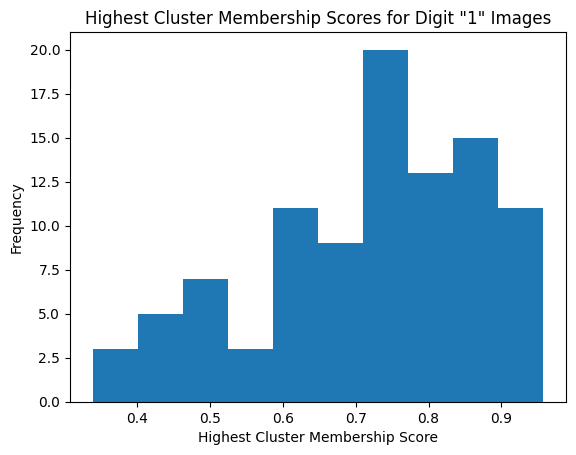

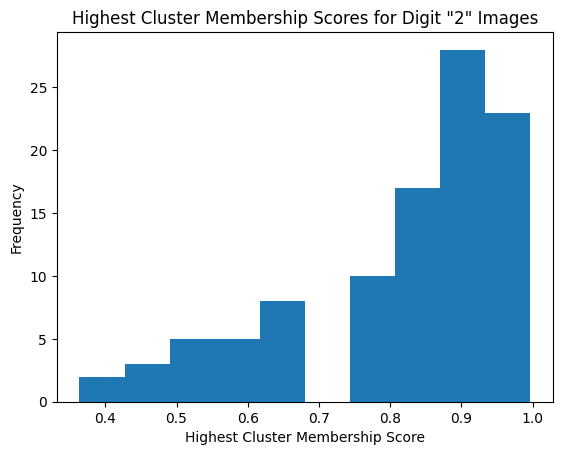

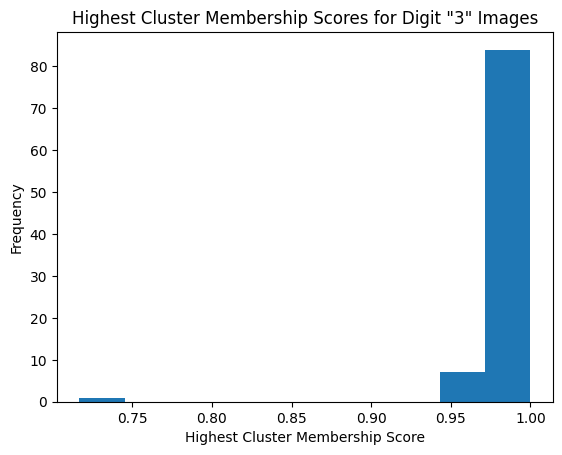

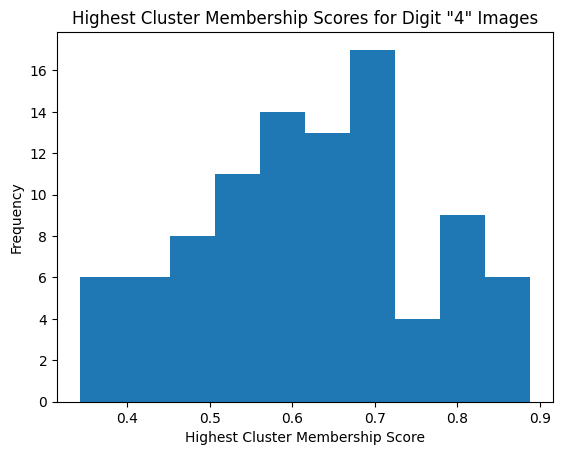

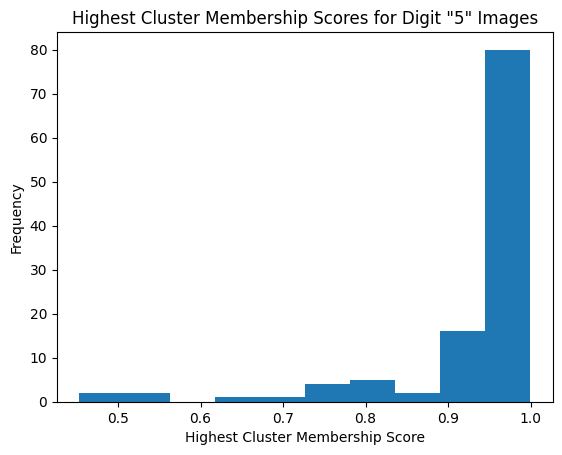

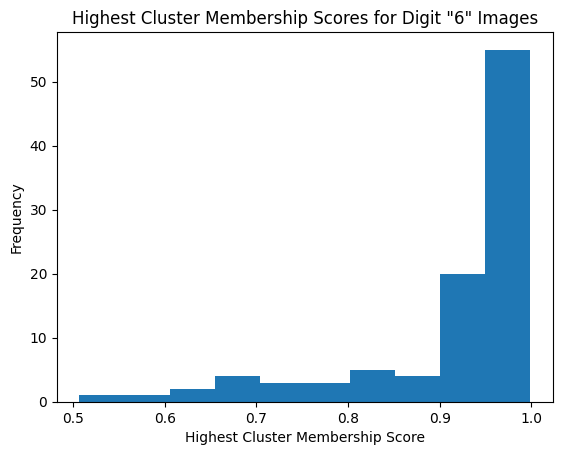

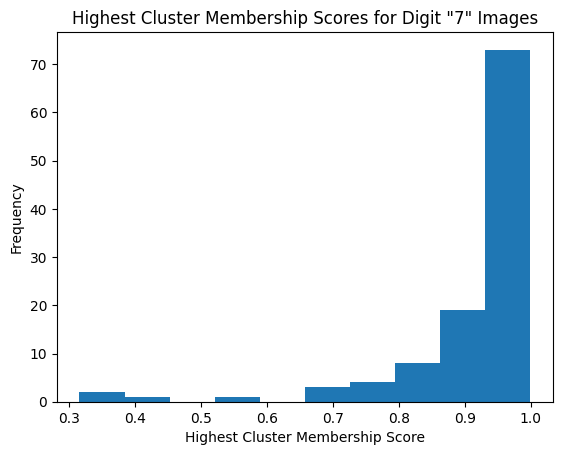

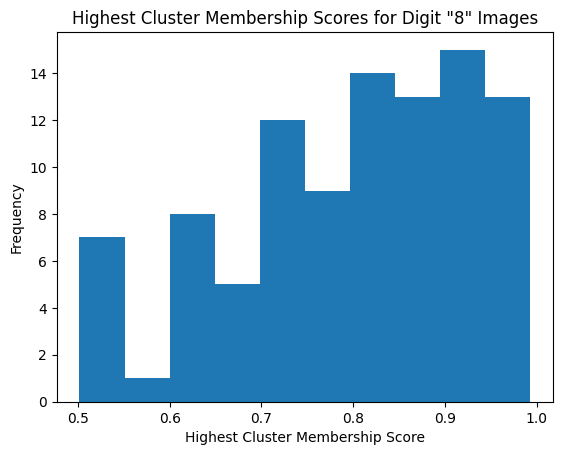

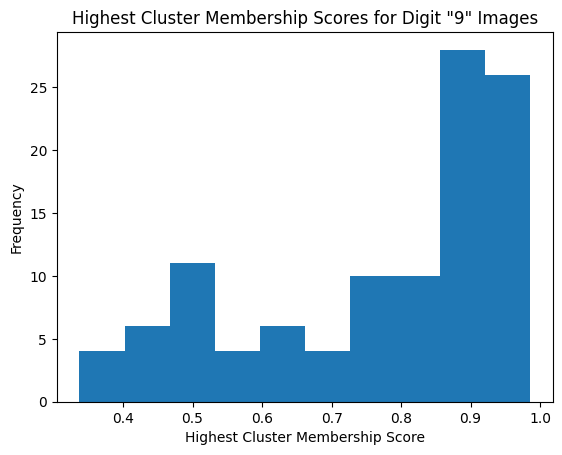

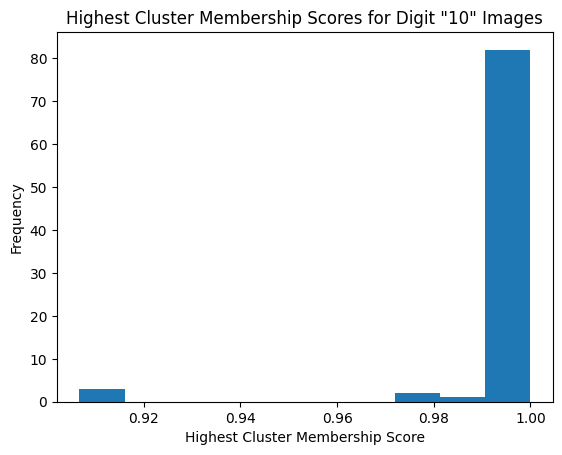

In [ ]:
for digit in range(1,11):
    #Find the highest membership score values just for images actually of the given digit
    digit_highest_membership_scores=highest_membership_scores[df['label']==digit]

    #visualize it
    plt.hist(digit_highest_membership_scores)
    plt.title('Highest Cluster Membership Scores for Digit "%s" Images'%(str(digit)))
    plt.xlabel('Highest Cluster Membership Score')
    plt.ylabel('Frequency')
    plt.show()

We see that images of the number '1','2','4','8','9'have the least certainty as to what cluster they should be assigned to in this clustering. We can see this relationship reflected in the t-SNE plots as well.

We see that images of the number '3','5','6','7','10' have the most certainty as to what cluster they should be assigned to in this clustering. We can see this relationship reflected in the t-SNE plots as well.

In [ ]:
def show_silhouette_plots(X,cluster_labels):

    # This package allows us to use "color maps" in our visualizations
    import matplotlib.cm as cm

    #How many clusters in your clustering?
    n_clusters=len(np.unique(cluster_labels))

    # Create a subplot with 1 row and 2 columns
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient fcan range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])


    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]


        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

        ax1.set_title("The silhouette plot for the various clusters.")
        ax1.set_xlabel("The silhouette coefficient values")
        ax1.set_ylabel("Cluster label")

        # The vertical line for average silhouette score of all the values
        ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

        ax1.set_yticks([])  # Clear the yaxis labels / ticks
        ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])


    plt.show()

    return

In [ ]:
from sklearn.metrics import adjusted_rand_score, silhouette_samples, silhouette_score

In [ ]:
partition_cluster_labels=[df_membership.T[i].argmax() for i in range(0,len(df_membership))]
df['predicted_cluster']=partition_cluster_labels

For n_clusters = 10 The average silhouette_score is : 0.08643679958680386


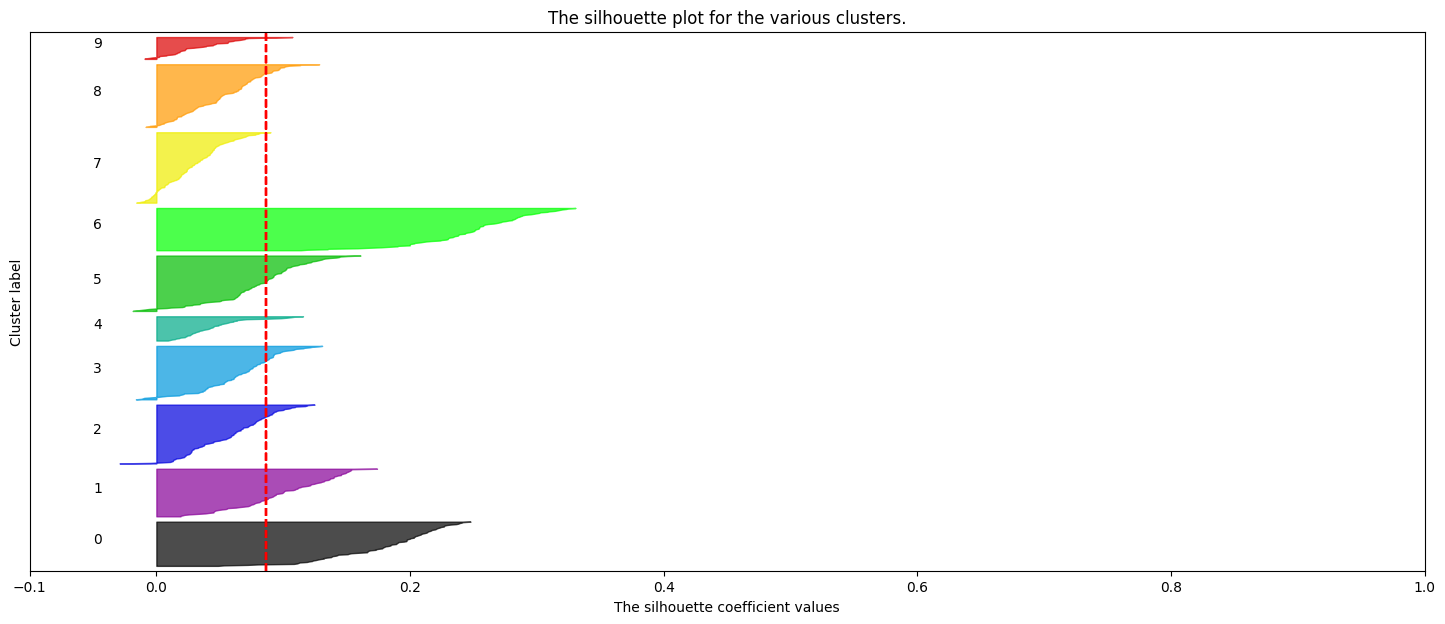

In [ ]:
show_silhouette_plots(X, df.predicted_cluster)

An average silhouette score of approximately 0.086 for N =10 suggests that the clustering outcome is not the best, as this value is quite close to 0. This low score indicates that the separation between the clusters is not very distinct, and the cohesion within the clusters is weak.

In [ ]:
df_fuzzyc = df.copy()

## 9. Clustering Algorithm #2

1.   PCA
2.   K Means



### PCA

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#from google.colab import files
#uploaded = files.upload()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df=df_pca.copy()
df.head()
df_org = df.copy()

In [ ]:
df_scaled = df.drop('label', axis = 1)
df_scaled = df_scaled/255
df_scaled.head()

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
X = StandardScaler(with_std=False).fit_transform(df_scaled)
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
C=np.cov(X.T)

In [ ]:
l, v = np.linalg.eig(C)
l_sort=np.sort(l)[::-1]
sort_order=np.argsort(l)[::-1]
cumvar=np.round(np.cumsum(l_sort)/np.sum(l_sort), 3)

/usr/local/lib/python3.10/dist-packages/matplotlib/cbook/__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


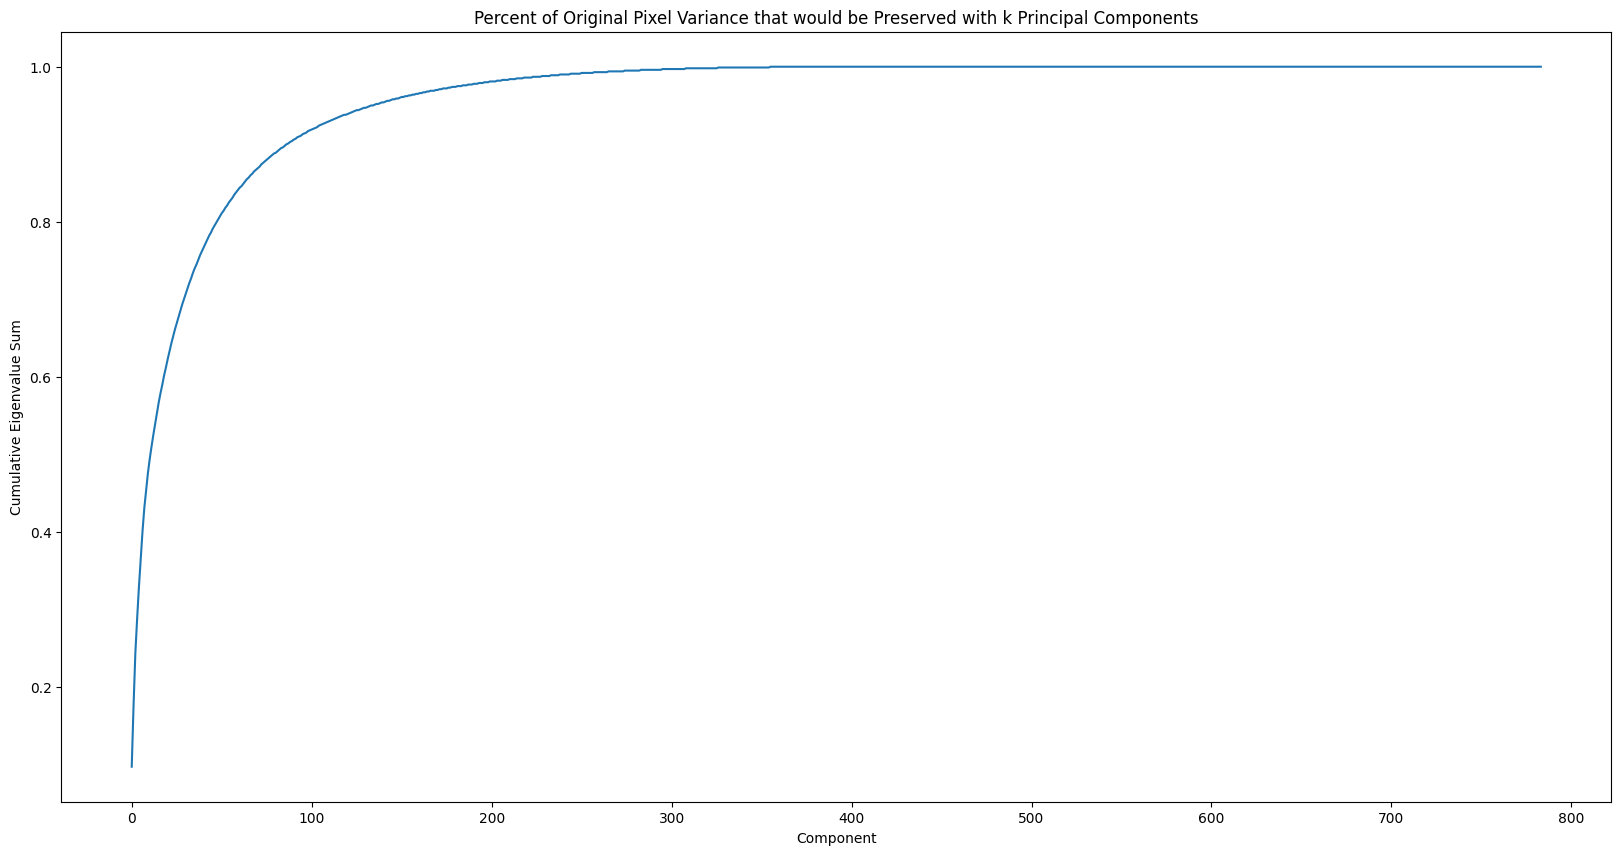

In [ ]:
plt.figure(figsize=(20,10))
plt.plot(cumvar)
plt.ylabel('Cumulative Eigenvalue Sum')
plt.xlabel('Component')
plt.title('Percent of Original Pixel Variance that would be Preserved with k Principal Components')
plt.show()

#### Parameter Selection

For this analysis, we wanted to have at least of 70% of the original maintained, it looks like have 30 components will preserve that percentage. To achieve an 80% variance preservation, we need about 50 components.

In [ ]:
print(np.where(cumvar >= 0.7)[0][0])
cumvar[np.where(cumvar >= 0.7)[0][0]]

29


(0.7+0j)

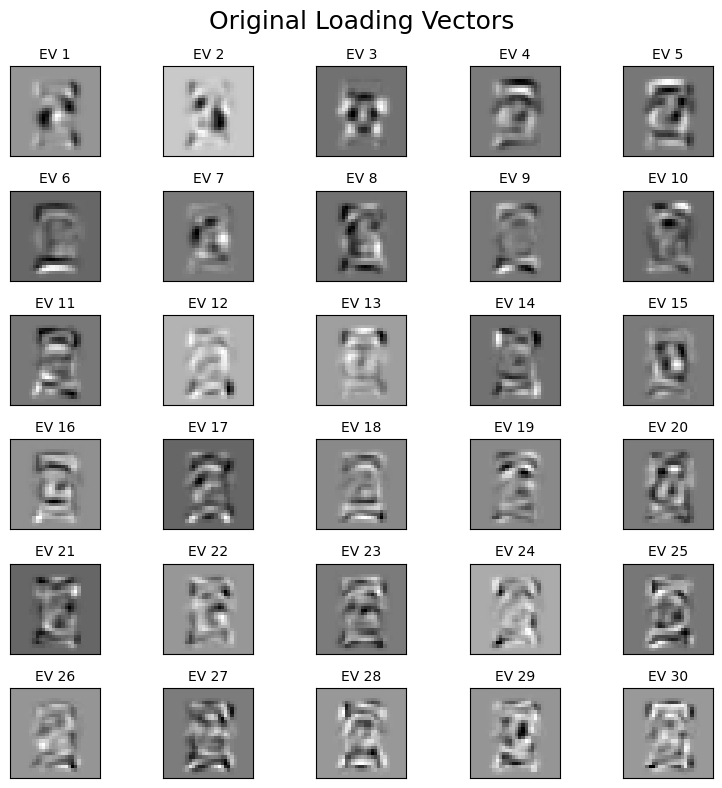

In [ ]:
pca = PCA(n_components=30, random_state=100)
Y = pca.fit_transform(X)
fig, ax = plt.subplots(6, 5, figsize=(8, 8))
fig.suptitle('Original Loading Vectors', fontsize=18)
for i in range(0,30):
  row = i//5
  col = i%5
  ax[row, col].set_title('EV %s'%str(i+1), {'fontsize': 10})
  ax[row, col].imshow(pca.components_[i].reshape((28, 28)), cmap='gray')
  ax[row, col].set_xticks([])
  ax[row, col].set_yticks([])
plt.tight_layout()
plt.show()

In [ ]:
X_original=df_scaled.copy()
pixel_means=X_original.mean()
mean_list=np.array(pixel_means)
mean_centered_eig=pca.components_+mean_list

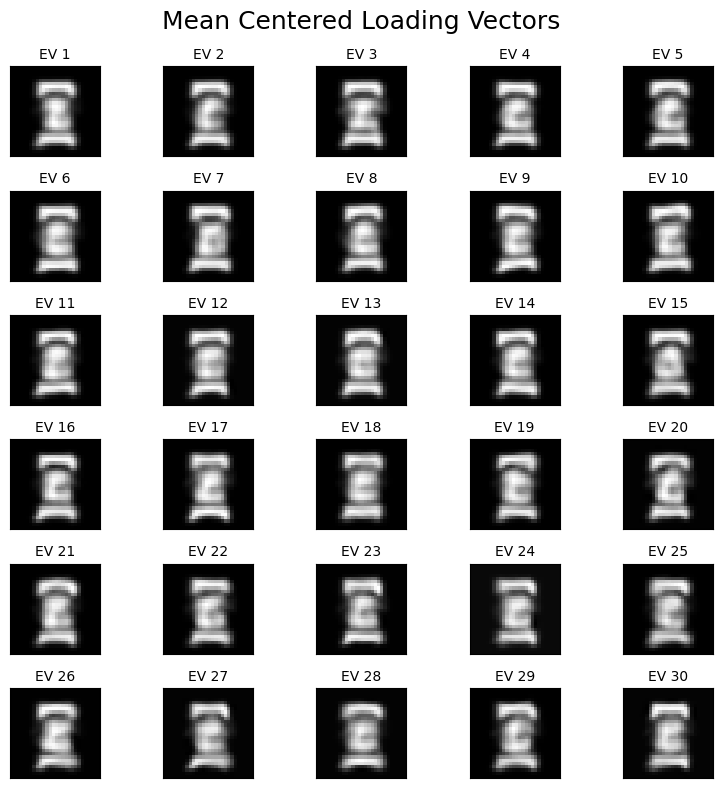

In [ ]:
fig, ax = plt.subplots(6, 5, figsize=(8, 8))
fig.suptitle('Mean Centered Loading Vectors', fontsize=18)
for i in range(0,30):
  row = i//5
  col = i%5
  ax[row, col].set_title('EV %s'%str(i+1), {'fontsize': 10})
  ax[row, col].imshow(mean_centered_eig[i].reshape((28, 28)), cmap='gray')
  ax[row, col].set_xticks([])
  ax[row, col].set_yticks([])
plt.tight_layout()
plt.show()

In [ ]:
df_components=pd.DataFrame(Y, columns=['principal_component_'+str(i) for i in range(0,30)])
df_data=pd.DataFrame(X,columns=['pixel_'+str(i) for i in range(0,784)])


df_data=pd.concat([df_data,df_components], axis=1)
df_data['label']=df_org['label']

In [ ]:
import seaborn as sns

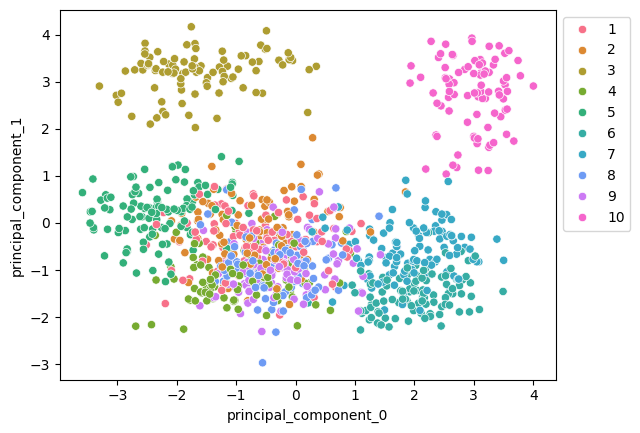

In [ ]:
sns.scatterplot(x='principal_component_0', y='principal_component_1', hue='label', palette=sns.color_palette("husl", 10), data=df_data)
plt.legend(bbox_to_anchor=(1,1))
plt.show()

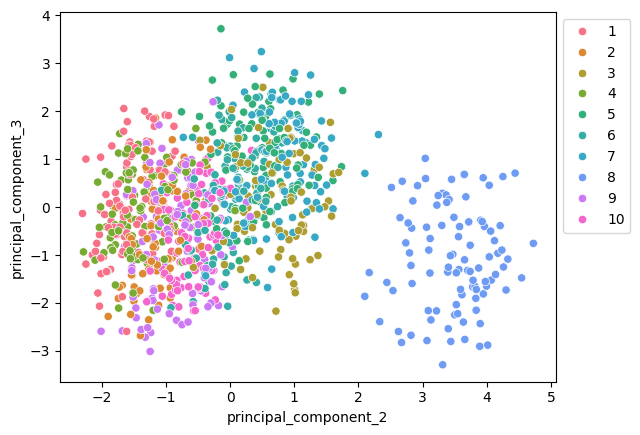

In [ ]:
sns.scatterplot(x='principal_component_2', y='principal_component_3', hue='label', palette=sns.color_palette("husl", 10), data=df_data)
plt.legend(bbox_to_anchor=(1,1))
plt.show()

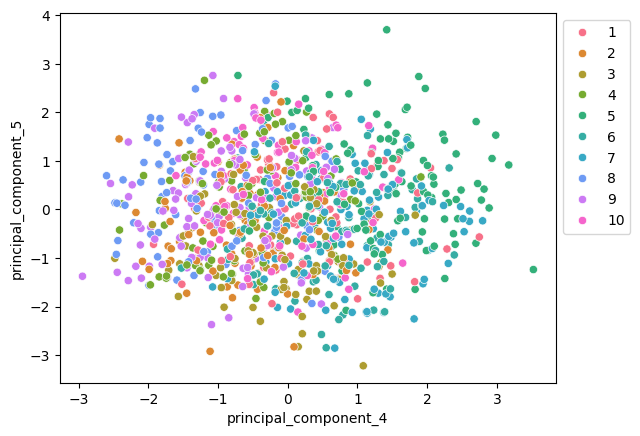

In [ ]:
sns.scatterplot(x='principal_component_4', y='principal_component_5', hue='label', palette=sns.color_palette("husl", 10), data=df_data)
plt.legend(bbox_to_anchor=(1,1))
plt.show()

In [ ]:
df_components.var()

principal_component_0     3.099003
principal_component_1     2.480164
principal_component_2     2.153460
principal_component_3     1.450576
principal_component_4     1.311386
principal_component_5     1.175447
principal_component_6     1.103219
principal_component_7     0.976470
principal_component_8     0.732204
principal_component_9     0.691291
principal_component_10    0.570992
principal_component_11    0.510443
principal_component_12    0.479843
principal_component_13    0.465625
principal_component_14    0.442007
principal_component_15    0.427640
principal_component_16    0.380404
principal_component_17    0.378494
principal_component_18    0.365425
principal_component_19    0.334892
principal_component_20    0.333145
principal_component_21    0.328965
principal_component_22    0.299852
principal_component_23    0.295029
principal_component_24    0.278091
principal_component_25    0.274210
principal_component_26    0.257325
principal_component_27    0.250711
principal_component_

#### Additional Exploration


Looking at the PC vs PC plots, we can see that there is clear seperation between digits 3, 10, and 8 with the rest of the digits

Shortcomings: Since this analysis focuses on PCA It is not particular appropriate to directly judge the seperation between the cluster, it suffers from similar drawbacks to T-SNE plots.

<Axes: xlabel='label', ylabel='principal_component_0'>

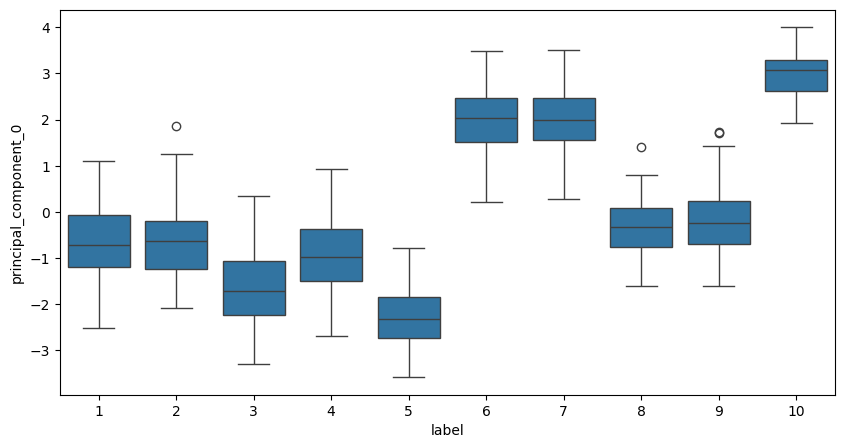

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(y="principal_component_0", x="label",data=df_data)

<Axes: xlabel='label', ylabel='principal_component_1'>

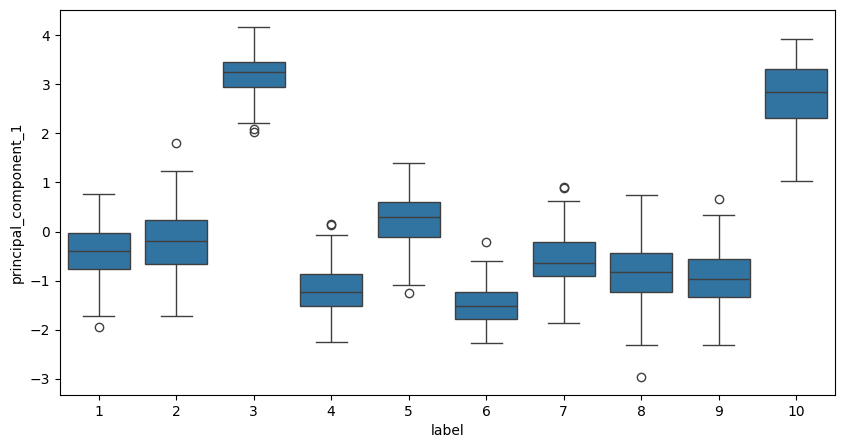

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(y="principal_component_1", x="label",data=df_data)

<Axes: xlabel='label', ylabel='principal_component_2'>

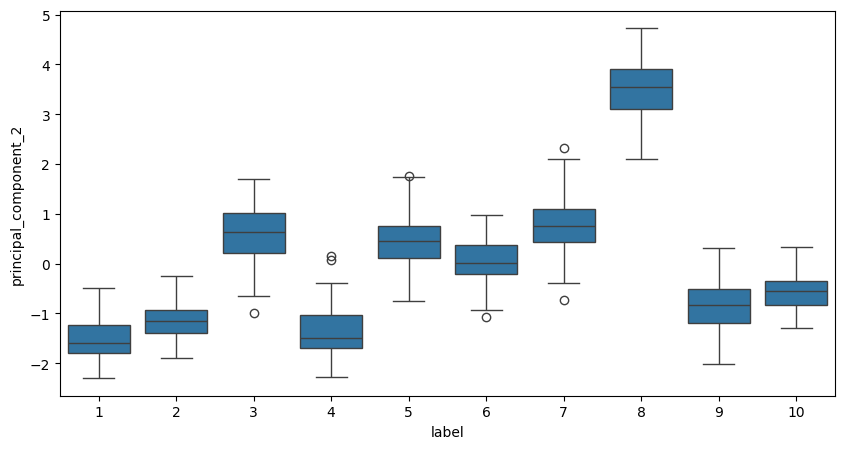

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(y="principal_component_2", x="label",data=df_data)

<Axes: xlabel='label', ylabel='principal_component_3'>

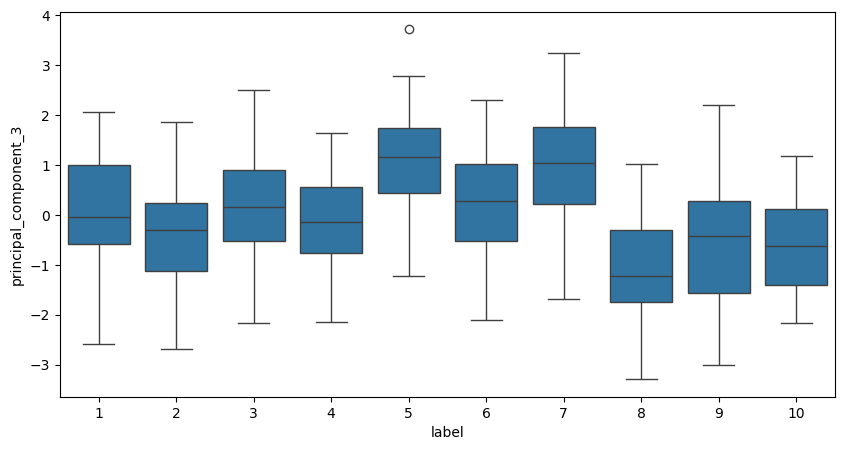

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(y="principal_component_3", x="label",data=df_data)

#### Describing the components

Looking at the first PC, we see that Digits 6, 7 and 10 have high magnitude within this compoonents. Digits 3 and 5 have very low magnitudes.

Looking at the second principal component, we see that it is highly positively correlated with Digit 3 and Digit 10. It is negatively correlated with Digit 4 and 6. Digits 1, 2, and 5 are have very low magnitude with this component

Looking at the third principal component, we see that it is highly positively correlated with Digit 8. It is negatively correlated with Digit 1, 2, and 4. Digits 9 and 10 have very low magnitude with this component

Component 4 seems to not have a high magnitude with most of the digits. Digits 5 and 7 have a higher positive median magnitude in this component while Digits 8, 9, and 10 have lower median magnitudes in this component

#### Eigen Images

Next, we will inverse transform the component and create some "Eigen Images" where these images will capture the primary features of each of the Digits

The reconstructed digits was able to capture the primary attributes in each images while significantly reducing the dimension the data.

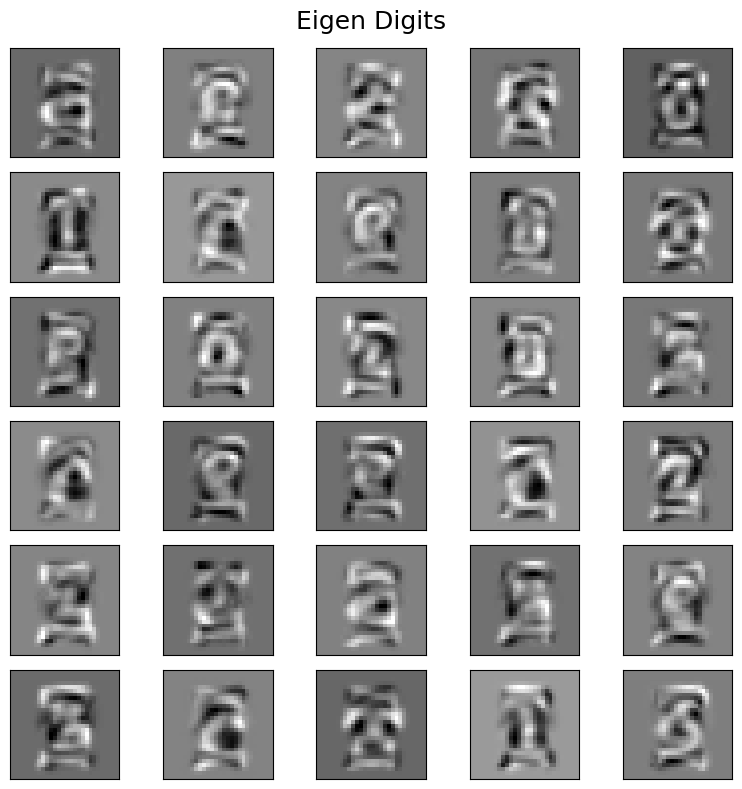

In [ ]:
components = pca.transform(X)
eigenimg = pca.inverse_transform(components)
fig, ax = plt.subplots(6, 5, figsize=(8, 8))
fig.suptitle('Eigen Digits', fontsize=18)
for i in range(0,30):
  row = i//5
  col = i%5
  #ax[row, col].set_title('EV %s'%str(i+1), {'fontsize': 10})
  ax[row, col].imshow(eigenimg[i].reshape((28, 28)), cmap='gray')
  ax[row, col].set_xticks([])
  ax[row, col].set_yticks([])
plt.tight_layout()
plt.show()

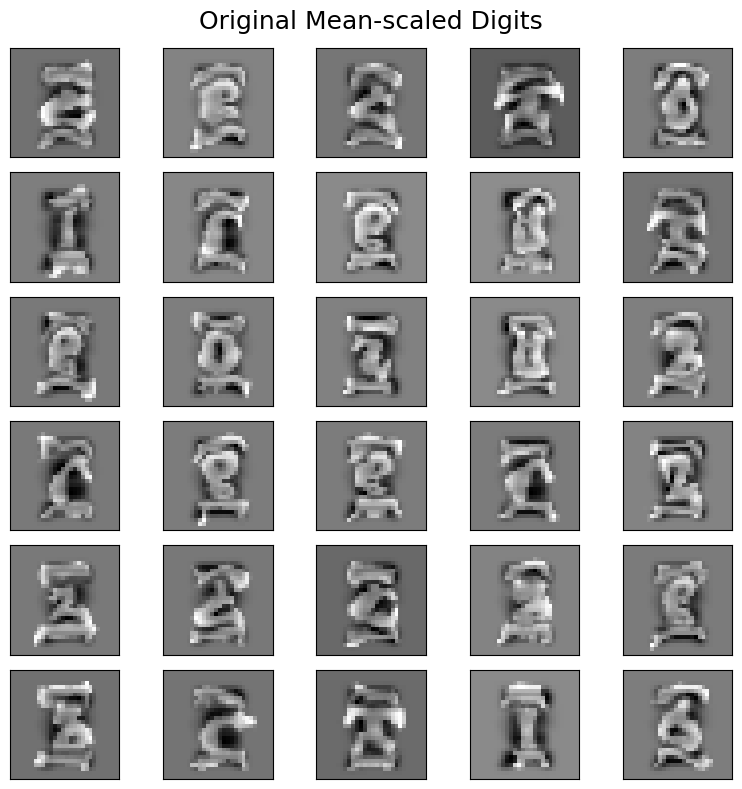

In [ ]:
fig, ax = plt.subplots(6, 5, figsize=(8, 8))
fig.suptitle('Original Mean-scaled Digits', fontsize=18)
for i in range(0,30):
  row = i//5
  col = i%5
  #ax[row, col].set_title('EV %s'%str(i+1), {'fontsize': 10})
  ax[row, col].imshow(X[i].reshape((28, 28)), cmap='gray')
  ax[row, col].set_xticks([])
  ax[row, col].set_yticks([])
plt.tight_layout()
plt.show()

### K-Means


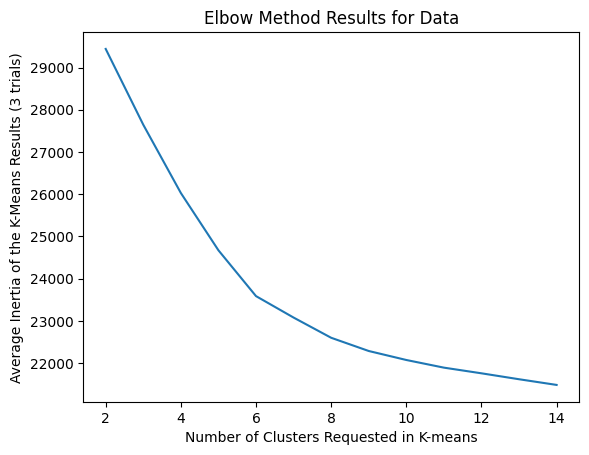

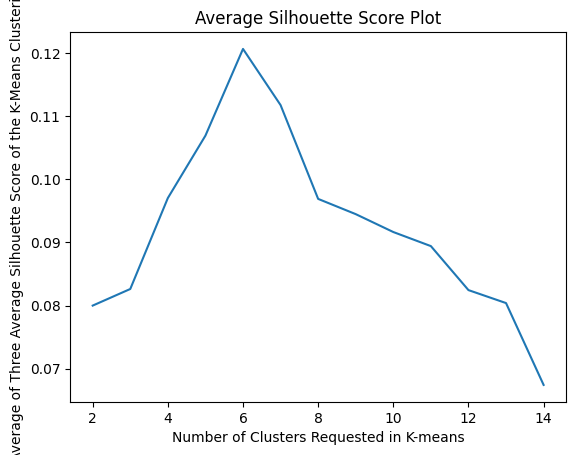

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings("ignore")

df_kmeans = df_org.copy()
df = df_kmeans.copy()
df_scaled = df.drop('label', axis = 1)
df_scaled = df_scaled/255
X = df_scaled

cluster_num_list=range(2,15)
avg_inertia_list=[]
avg_avg_sil_score_list=[]
for k in cluster_num_list:
    sub_inertia_list=[]
    avg_sil_score_list=[]
    for i in range(0,3):
        kmeans=KMeans(n_clusters=k).fit(X)
        sub_inertia_list.append(kmeans.inertia_)
        cluster_labels = kmeans.labels_
        avg_sil_score=silhouette_score(X, cluster_labels)
        avg_sil_score_list.append(avg_sil_score)
    avg_inertia_list.append(np.average(sub_inertia_list))
    avg_avg_sil_score_list.append(np.average(avg_sil_score_list))

plt.plot(cluster_num_list,avg_inertia_list)
plt.xlabel('Number of Clusters Requested in K-means')
plt.ylabel('Average Inertia of the K-Means Results (3 trials)')
plt.title('Elbow Method Results for Data')
plt.show()
plt.plot(cluster_num_list,avg_avg_sil_score_list)
plt.xlabel('Number of Clusters Requested in K-means')
plt.ylabel('Average of Three Average Silhouette Score of the K-Means Clusterings')
plt.title('Average Silhouette Score Plot')
plt.show()

#### Parameter Selection

We will use both the Elbow and the Silhouette methods to kind the optimal K. Both methods suggest k=6

In [ ]:
kmeans=KMeans(n_clusters=6, random_state=100).fit(X)
df['predicted_cluster']=kmeans.labels_
centroids = kmeans.cluster_centers_

In [ ]:
from sklearn.metrics import adjusted_rand_score

In [ ]:
def show_silhouette_plots(X,cluster_labels):

    # This package allows us to use "color maps" in our visualizations
    import matplotlib.cm as cm

    #How many clusters in your clustering?
    n_clusters=len(np.unique(cluster_labels))

    # Create a subplot with 1 row and 2 columns
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient fcan range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])


    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]


        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

        ax1.set_title("The silhouette plot for the various clusters.")
        ax1.set_xlabel("The silhouette coefficient values")
        ax1.set_ylabel("Cluster label")

        # The vertical line for average silhouette score of all the values
        ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

        ax1.set_yticks([])  # Clear the yaxis labels / ticks
        ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])


    plt.show()

    return

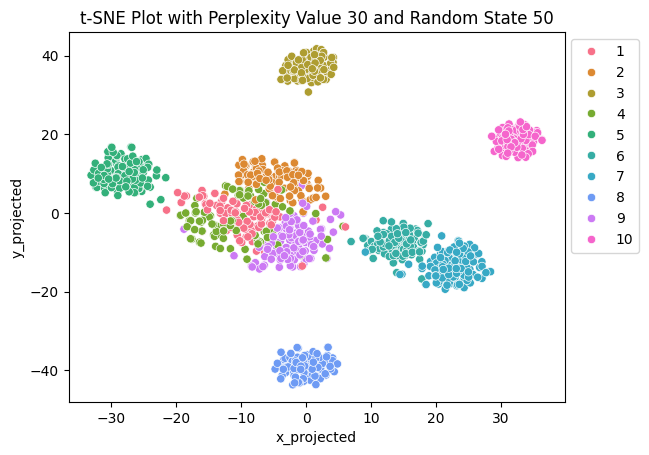

--------------------------------------------


In [ ]:
for perp in [30]:
    for rs in [50]:
        tsne = TSNE(n_components=2, perplexity=perp, random_state=rs)
        data_tsne = tsne.fit_transform(X)
        df_tsne = pd.DataFrame(data_tsne, columns=['x_projected', 'y_projected'])
        df_combo = pd.concat([df, df_tsne], axis=1)
        sns.scatterplot(x='x_projected',y='y_projected', hue='label', palette=sns.color_palette("husl", 10), data=df_combo)
        plt.title('t-SNE Plot with Perplexity Value %s and Random State %s' %(perp, rs))
        plt.legend(bbox_to_anchor=(1,1))
        plt.show()
    print('--------------------------------------------')

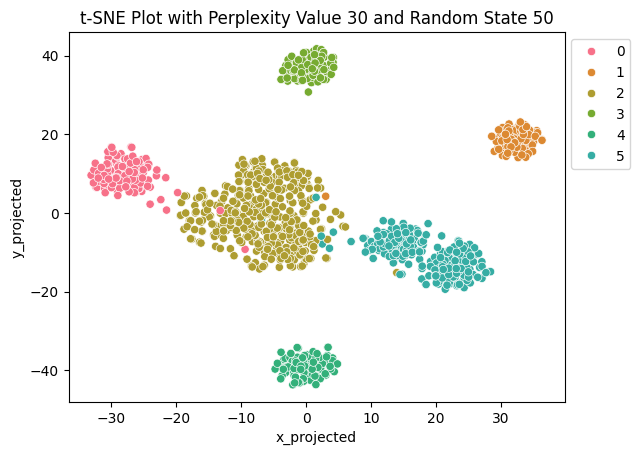

--------------------------------------------


In [ ]:
for perp in [30]:
    for rs in [50]:
        tsne = TSNE(n_components=2, perplexity=perp, random_state=rs)
        data_tsne = tsne.fit_transform(X)
        df_tsne = pd.DataFrame(data_tsne, columns=['x_projected', 'y_projected'])
        df_combo = pd.concat([df, df_tsne], axis=1)
        sns.scatterplot(x='x_projected',y='y_projected', hue='predicted_cluster', palette=sns.color_palette("husl", 10), data=df_combo)
        plt.title('t-SNE Plot with Perplexity Value %s and Random State %s' %(perp, rs))
        plt.legend(bbox_to_anchor=(1,1))
        plt.show()
    print('--------------------------------------------')

#### Clustering Results

Looking at the T-SNE plots with the true Digit labels and the cluster labels, we see that Digits 6 and 7 have been merged by k-means. Digits 3, 5, 8, 10 retained independent clusters. The k-means merged Digits 1, 2, 4 and 9 into the large cluster.

#### Finding the Inhernet Clusters

K-means was able to locate the clusters with good seperation. However it merged every Digits that had poor distinct seperation to another digit. Comparing the T-SNE plots, we see the very distinct digits were classified correctly, There are only a few mis-identification between Cluster 0 (Digit 5) and Cluster 2. Cluster 5 (Digits 6 and 7) also had some but overall k-means was able to find the inhernet structure as long as it is not too similar.

In [ ]:
df_centroids=pd.DataFrame(centroids, columns=X.columns)

In [ ]:
adjusted_rand_score(df['label'], df['predicted_cluster'])

0.5085916429368816

For n_clusters = 6 The average silhouette_score is : 0.1206651655459346


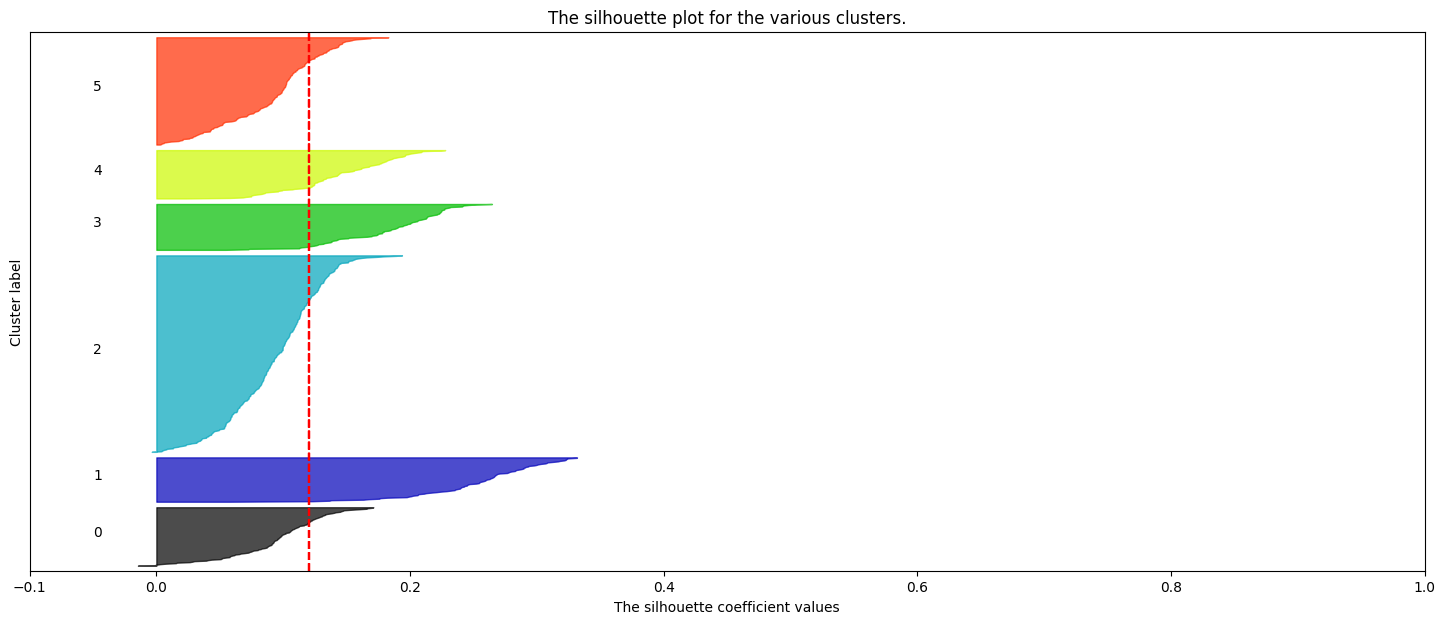

In [ ]:
show_silhouette_plots(X, df['predicted_cluster'])

In [ ]:
from scipy.spatial.distance import pdist, squareform

In [ ]:
df_sort = df.sort_values(by=['predicted_cluster'])
df_sort = df_sort.drop(['predicted_cluster'], axis=1)


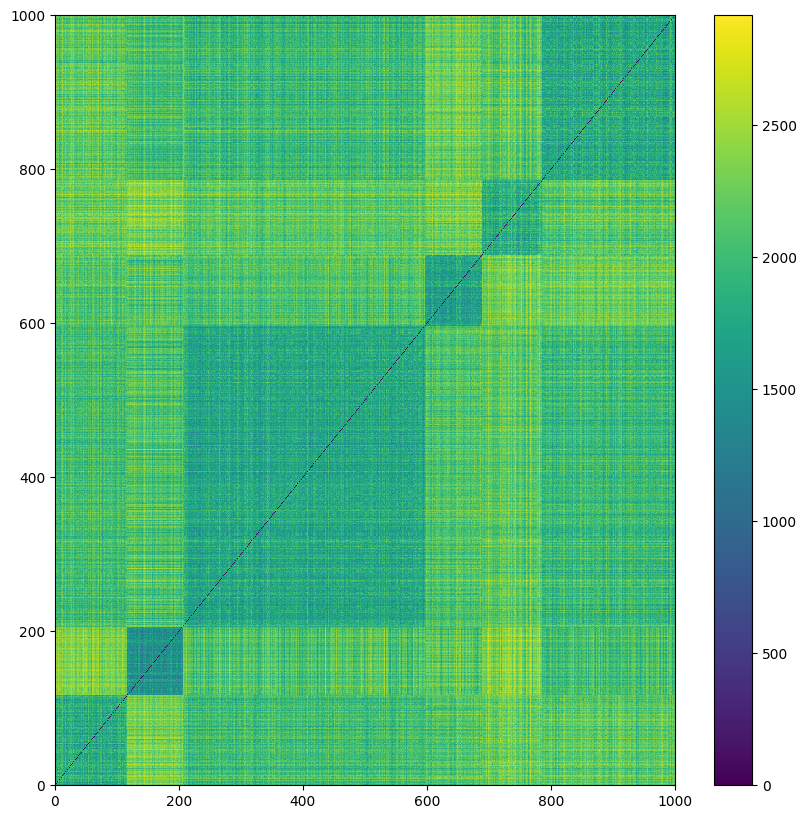

In [ ]:
#Create a distance matrix
dist_mat = squareform(pdist(df_sort))

#Then visualize the distance matrix with a heat map.
plt.figure(figsize=(10,10))
plt.pcolormesh(dist_mat)
plt.colorbar()
N = len(df_sort)
plt.xlim([0,N])
plt.ylim([0,N])
plt.show()

#### Additional Cluster Exploration

Looking at the shilhouette plot, Cluster 1 has the best cohesion and seperation while cluster 0 and 5 have the worst cohesion and seperation. The overal silhouette score the clustering is poor.

Looking the Cluster Sorted Similarity Matrix Plot, we see that the overal similarity is poor as indicated by the lack of dark blue shading on the plot. The cluster with the best similarity is cluter 1 followed by 3. Cluster 0 has the worst within cluster similarity but has a strong dissimilarity to cluster 1 and 4. Cluster 1 also is strongly dissimilar to cluster 4.

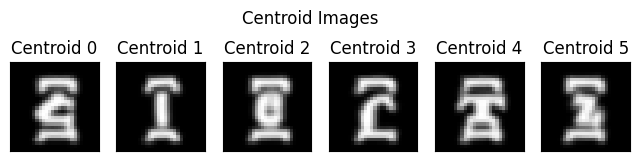

In [ ]:
fig, ax = plt.subplots(1, 6, figsize=(8, 2))
plt.suptitle('Centroid Images')
for j in range(6):
  #Turn the centroids into a dataframe

  #First, reshape the flattened 64 pixel array into an 8-by-8 numpy array and unscale the data (ie. multiply by 255)
  object_image = np.array(df_centroids.iloc[j]).reshape((28,28))*255

  #Then show the image
  ax[j].imshow(object_image, cmap='gray')
  ax[j].grid(False)
  ax[j].set_xticks([])
  ax[j].set_yticks([])
  ax[j].set_title('Centroid %s'%str(j))
plt.show()

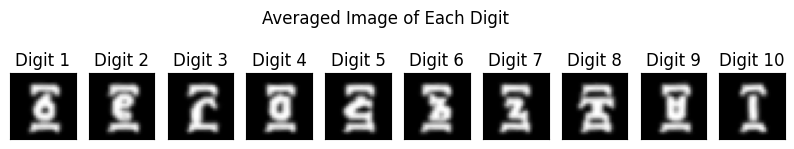

In [ ]:
#Set up the plot
fig, ax = plt.subplots(1, 10, figsize=(10, 2))
plt.suptitle('Averaged Image of Each Digit')

for digit in range(10):
    object_image = np.array(df_digit_averages.iloc[digit]).reshape((28, 28))*255

    #Then show the image
    ax[digit].imshow(object_image, cmap='gray')
    ax[digit].grid(False)
    ax[digit].set_xticks([])
    ax[digit].set_yticks([])
    ax[digit].set_title('Digit %s'%str(digit+1))
plt.show()

#### Describing Each of the Clusters

Since the Assignment has been very clear, Centroid 0 is mostly Digit 5, Centroid 1 is Digit 10, Centroid 2 is composed of Digits 1, 2, 4, 9, Centroid 3 contains only Digit 3, Centroid 4 is Digits 6 and 7. With Centroid 5 being composed of Digit 8

Looking at the centroid images. The Centroid 2 Image is by far the most blurry as it incompasses 4 very similar digits. Centroid 5 looks like a Digit 7 and less of a combination of 6 and 7. Other centroids are very distinct

## 10. Discussion

Our Fuzzy C-means algoithm with a p=1.09 gave us a hard assignment to a lot of it's objects, however, now we had some nodes that may be on the "outskirts" of their respective clusters have fuzzier cluster membership weights The normalized dunning partitional coefficient for this clustering is also 0.7787. This might imply that Fuzzy C-means can provide soft cluster assignments but the interpretability of these assignments might not be straightforward in the context of image data like MNIST. The soft boundaries produced by FCM may not align well with the inherent structure of handwritten digits. The Fuzzy C-means was able to identify that there were outliers or straddle nodes.

We believe that the Fuzzy C-means was better able to identify all the "inherent" clusters that exist in this datase because of its robustness to noise due to it considers the degree of membership for each data point makes it better than K-means, which was only able to identify 3 of the 10 inherent clusters.

The clustering was quite useful as it showcased what digits tends to have similarity and what digits are very distinct. Both algorithm were able to locate the distinct cluster but fuzzy-c means allowed for fuzzy assignment on the not-so-distinct ones.

PCA reduces the dimensionality of the data by projecting it onto a lower-dimensional subspace. PCA returns solid results when used in a image downsampling role. PCA was also able to illuminate some useful correlations between the digits but was unable to give a clear clustering.

Because K-means was able to detect only very distinct cluster it had poor cluster similarity and cohesion. Fuzzy can detect the relationship between single data point to multiple clusters, but kmeans can not.


## 11. Conclusion

**Summary** Both Fuzzy C means and K-means were successful in finding useful clustering solution, PCA was successful in a image downsample role

**Reconmmendation**
We would reconmmend using Fuzzy c-means to find similarites between the digits. Especially the cluster membership scores as they are a good indicator of what

**Shortcomings**
Fuzzy C-means assumes that clusters are spherical and isotropic. This may not hold true for all datasets, leading to suboptimal clustering results in cases where clusters have non-spherical shapes or different densities. This could be true from the low average silhouette score that there might not have a inherently spherical shape. In addition, K-means had a difficult time distinguishing the 4 digits with high similarity.

**Future Work** A potential idea that we thought of was to perform K-Means in conjunction with PCA which will allows to analyze the clustering results generated by the K-means algorithm and explore the within cluster digit/image correlation

## References

Afro-Mnist - Github Pages, 2020, pml4dc.github.io/iclr2020/papers/PML4DC2020_34.pdf.

David M. Eberhard, Gary F Simons, and Charles D Fennig. Languages of the world, 2019. URL
http://www.ethnologue.com/.

Emmanuel Mfanafuthi Mgqwashu. Academic literacy in the mother tongue: A pre-requisite for
epistemological access. Diversity, Transformation and Student Experience in Higher Education
Teaching and Learning, pp. 159, 2011.